# EDA, calidad de datos, preprocesamiento, pipelines y baseline

**Aprendizaje de Máquina Aplicado**

**Estudiantes:**
- Patricia Arango
- Santiago Higuita
- Alexander Pelaez

Repositorio del Proyecto: [Github](https://github.com/AlexanderPelaezJimenez/ml_project_eafit/tree/main)
___

**Universidad EAFIT**       
**Fecha:** 2026

---
## Tabla de Contenidos

1. **Introducción y problema**
2. **Setup reproducible**
3. **Carga del dataset**
4. **Auditoría de calidad**
   - 4.1 Schema y tipos
   - 4.2 Análisis de nulos
   - 4.3 Duplicados
   - 4.4 Variables de baja varianza
5. **Análisis del target**
   - 5.1 Distribución del puntaje global
   - 5.2 Composición del target (leakage)
6. **EDA univariado y bivariado**
   - 6.1 Variables socioeconómicas vs target
   - 6.2 Variables del colegio vs target
   - 6.3 Asociación de features con el target (correlation ratio)
   - 6.4 Análisis temporal
   - 6.5 Análisis geográfico
7. **Análisis avanzado**
   - 7.1 Brechas de equidad
   - 7.2 Interacciones y efectos confundidos
   - 7.3 Análisis jerárquico (ICC)
8. **Feature engineering preliminar**
9. **Split y protocolo anti-leakage**
10. **Baseline**
11. **Hallazgos, decisiones y próximos pasos**

---
## Introducción & Problema

El presente proyecto busca responder la siguiente pregunta:

### Pregunta a Responder
¿en qué medida las condiciones socioeconómicas y las características del entorno educativo de los estudiantes 
colombianos permiten explicar y pronosticar su Puntaje Global en el examen Saber 11?

### Introducción:

Este proyecto se resolverá como un problema de aprendizaje supervisado, específicamente una regresión, donde la variable objetivo, Puntaje Global (escala continua de 0 a 500 puntos) y las variables predictoras (características) son un subconjunto de atributos socioeconómicos, familiares e institucionales disponibles en el conjunto de datos. Concretamente, el modelo pretende cuantificar la influencia de factores como el estrato socioeconómico, el nivel educativo de los padres, el acceso a recursos tecnológicos, la naturaleza del colegio, su ubicación geográfica y otras variables del contexto familiar y escolar, sobre el desempeño académico del estudiante.

---

##  Setup reproducible: Configuración del Entorno

In [1]:
# Configuración inicial del entorno
import sys
import warnings

warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 9), "Este notebook requiere Python 3.9 o superior"

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} instalado correctamente")

Python 3.14.3 instalado correctamente


---
## Carga del dataset <a name="datos"></a>

### El dataset saber 11 desde datos abiertos del Gobierno de Colombia

**Origen**: Datos Abiertos del Gobiernos de Colombia
**Tamaño**: 7.1 M de registros a la fecha de descarga (abr 2026)
**Granularidad**: Cada fila es un estudiante

### ¿Por qué este dataset?

- El dataset “Resultados únicos Saber 11”, publicado por el ICFES en el portal de Datos Abiertos del Gobierno de Colombia
- Al tener aproximadamente 7.1 millones de registros y 51 columnas que abarcan múltiples periodos, su volumen permite entrenar modelos confiables y con buena capacidad de generalización
- Al ser una fuente oficial y abierta, los datos son confiables y reproducibles. 


In [2]:
from pathlib import Path

import polars as pl
from loguru import logger

In [3]:
DATA_DIR = Path("../data/raw")

def update_consolidate(folder: str, format: str = "parquet"):

    logger.info(f'Cargando datos desde {folder} con formato {format}...')
    return pl.scan_parquet(f"{folder}/*.{format}").collect()

all_dataset = update_consolidate(DATA_DIR, format="parquet")
all_dataset.head(5).show()

2026-04-26 22:07:35.226 | INFO     | __main__:update_consolidate:5 - Cargando datos desde ../data/raw con formato parquet...


cole_nombre_establecimiento,punt_ingles,estu_cod_depto_presentacion,cole_sede_principal,punt_matematicas,estu_cod_reside_mcpio,cole_caracter,fami_cuartoshogar,desemp_ingles,fami_educacionpadre,estu_tipodocumento,estu_fechanacimiento,estu_estadoinvestigacion,estu_cod_reside_depto,fami_tienecomputador,estu_genero,cole_cod_dane_sede,punt_lectura_critica,fami_tienelavadora,fami_personashogar,estu_depto_presentacion,cole_cod_depto_ubicacion,estu_cod_mcpio_presentacion,estu_depto_reside,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_naturaleza,punt_sociales_ciudadanas,cole_calendario,estu_mcpio_reside,periodo,cole_genero,fami_estratovivienda,cole_area_ubicacion,cole_cod_dane_establecimiento,cole_nombre_sede,estu_privado_libertad,cole_bilingue,cole_mcpio_ubicacion,punt_c_naturales,estu_mcpio_presentacion,fami_educacionmadre,estu_consecutivo,fami_tieneautomovil,estu_nacionalidad,cole_jornada,estu_pais_reside,punt_global,fami_tieneinternet,cole_depto_ubicacion,estu_estudiante
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""GIMN FEMENINO""","""94""","""11""","""S""","""88""","""11001""","""ACADÉMICO""","""Cuatro""","""B+""","""Educación profesional completa""","""CR""","""08/08/1994""","""PUBLICAR""","""11""","""Si""","""F""","""311848000812""",null,"""Si""","""Cuatro""","""BOGOTÁ""","""11""","""11001""","""BOGOTÁ""","""11001""","""022574""","""NO OFICIAL""",null,"""B""","""BOGOTÁ D.C.""","""20131""","""FEMENINO""","""Estrato 6""","""URBANO""","""311848000812""","""GIMN FEMENINO""","""N""","""N""","""BOGOTÁ D.C.""",null,"""BOGOTÁ D.C.""","""Educación profesional completa""","""SB11201310000414""","""Si""","""COLOMBIA""","""COMPLETA""","""COLOMBIA""",null,"""Si""","""BOGOTA""","""ESTUDIANTE"""
"""INSTITUCION EDUCATIVA JESUS MA…","""71""","""41""","""N""","""66""","""41016""","""TÉCNICO/ACADÉMICO""","""Dos""","""B1""","""Primaria completa""","""TI""","""15/02/2003""","""PUBLICAR""","""41""","""Si""","""F""","""241016000342""","""69""","""Si""","""1 a 2""","""HUILA""","""41""","""41016""","""HUILA""","""41016""","""194878""","""OFICIAL""","""70""","""A""","""AIPE""","""20194""","""MIXTO""","""Estrato 2""","""RURAL""","""141016000305""","""DINDAL""","""N""","""N""","""AIPE""","""65""","""AIPE""","""Postgrado""","""SB11201940464873""","""No""","""COLOMBIA""","""COMPLETA""","""COLOMBIA""","""339""","""Si""","""HUILA""","""ESTUDIANTE"""
"""INSTITUCION EDUCATIVA JESUS MA…","""71""","""41""","""N""","""66""","""41016""","""TÉCNICO/ACADÉMICO""","""Dos""","""B1""","""Primaria completa""","""TI""","""15/02/2003""","""PUBLICAR""","""41""","""Si""","""F""","""241016000342""","""69""","""Si""","""1 a 2""","""HUILA""","""41""","""41016""","""HUILA""","""41016""","""194878""","""OFICIAL""","""70""","""A""","""AIPE""","""20194""","""MIXTO""","""Estrato 2""","""RURAL""","""141016000305""","""DINDAL""","""N""","""N""","""AIPE""","""65""","""AIPE""","""Postgrado""","""SB11201940464873""","""No""","""COLOMBIA""","""COMPLETA""","""COLOMBIA""","""339""","""Si""","""HUILA""","""ESTUDIANTE"""
"""INSTITUCION EDUCATIVA ANTONIO …","""48""","""63""","""S""","""45""","""63130""","""TÉCNICO/ACADÉMICO""","""Dos""","""A1""","""No sabe""","""TI""","""20/05/1996""","""PUBLICAR""","""63""","""Si""","""F""","""163130000718""",null,"""No""","""Cuatro""","""QUINDIO""","""63""","""63130""","""QUINDIO""","""63130""","""013029""","""OFICIAL""",null,"""A""","""CALARCÁ""","""20122""","""MIXTO""","""Estrato 1""","""URBANO""","""163130000718""","""ANTONIO NARIÑO""","""N""","""N""","""CALARCÁ""",null,"""CALARCÁ""","""Secundaria (Bachillerato) inco…","""SB11201220204399""","""No""","""COLOMBIA""","""MAÑANA""","""COLOMBIA""",null,"""Si""","""QUINDIO""","""ESTUDIANTE"""
"""CRISTO REY""","""43""","""19""","""S""","""52""","""19001""","""TÉCNICO""","""Cinco""","""A-""","""Educación profesional incomple…","""TI""","""19/03/1997""","

---
## Análisis Exploratorio de Datos

### 4. Auditoría de Calidad

In [4]:
import os
import sys

PARENT_DIR = os.path.dirname(os.getcwd())

sys.path.append(f'{PARENT_DIR}/src')

#### 4.1 Schema y tipos

In [5]:
from eda_utils import summarize_schema, cast_numeric_columns

global_schema = summarize_schema(all_dataset, target='punt_global')

global_schema

column,dtype,non_null,missing,missing_pct,n_unique,role
str,str,i64,i64,f64,i64,str
"""punt_global""","""String""",4500181,2609523,36.7,482,"""target"""
"""punt_sociales_ciudadanas""","""String""",4500181,2609523,36.7,101,"""feature"""
"""punt_lectura_critica""","""String""",4500181,2609523,36.7,95,"""feature"""
"""punt_c_naturales""","""String""",4500181,2609523,36.7,92,"""feature"""
"""cole_bilingue""","""String""",6192834,916870,12.9,3,"""feature"""
…,…,…,…,…,…,…
"""estu_pais_reside""","""String""",7109704,0,0.0,92,"""feature"""
"""punt_matematicas""","""String""",7109704,0,0.0,307,"""feature"""
"""cole_sede_principal""","""String""",7109681,23,0.0,3,"""feature"""


In [6]:
cols_puntaje = [
    'punt_global',
    'punt_sociales_ciudadanas',
    'punt_lectura_critica',
    'punt_matematicas', 
    'punt_c_naturales',
    'punt_ingles'
]

all_dataset = cast_numeric_columns(all_dataset, cols_puntaje)

all_dataset.select(cols_puntaje).describe().show()

statistic,punt_global,punt_sociales_ciudadanas,punt_lectura_critica,punt_matematicas,punt_c_naturales,punt_ingles
str,f64,f64,f64,f64,f64,f64
"""count""",4.500181e6,4.500181e6,4.500181e6,6.407897e6,4.500181e6,6.403099e6
"""null_count""",2.609523e6,2.609523e6,2.609523e6,701807.0,2.609523e6,706605.0
"""mean""",252.303317,48.865358,52.184939,49.223683,50.10606,48.425549
"""std""",50.426683,11.730556,10.385772,12.062366,10.569585,12.342203
"""min""",0.0,0.0,0.0,0.0,0.0,-1.0


#### 4.2 Análisis de Nulos

**Hallazgo:** 36.7% de registros sin `punt_global`, concentrados en periodos pre-2014 (mecanismo MAR).

**Decisión:** Filtrar registros sin target. No se puede entrenar ni evaluar sin la variable objetivo.

In [7]:
from eda_utils import missing_summary, plot_missing_bars, plot_nulls_by_period

result = missing_summary(all_dataset)

cant = result.filter(pl.col('missing') > 0).height
print(f"Número de columnas con valores faltantes: {cant} ({(cant / result.height * 100):.2f}% de las columnas totales)")
result.head(10)

Número de columnas con valores faltantes: 44 (86.27% de las columnas totales)


column,missing,missing_pct,dtype
str,i64,f64,str
"""punt_lectura_critica""",2609523,36.7,"""Int64"""
"""punt_sociales_ciudadanas""",2609523,36.7,"""Int64"""
"""punt_c_naturales""",2609523,36.7,"""Int64"""
"""punt_global""",2609523,36.7,"""Int64"""
"""cole_bilingue""",916870,12.9,"""String"""
"""punt_ingles""",706605,9.94,"""Int64"""
"""punt_matematicas""",701807,9.87,"""Int64"""
"""fami_estratovivienda""",218219,3.07,"""String"""
"""fami_educacionmadre""",212826,2.99,"""String"""


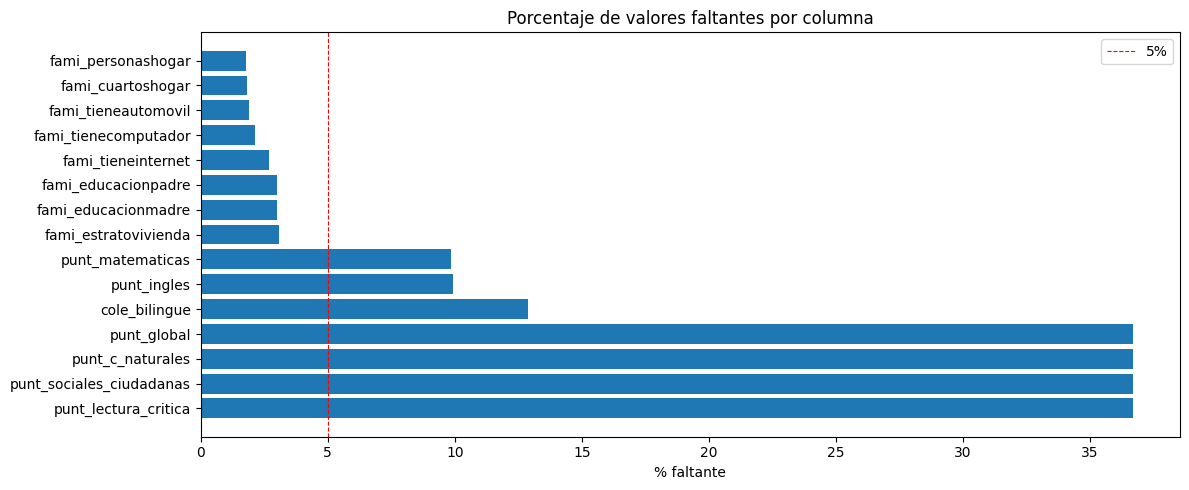

In [8]:
plot_missing_bars(all_dataset.select(result.head(15)['column'].to_list()))

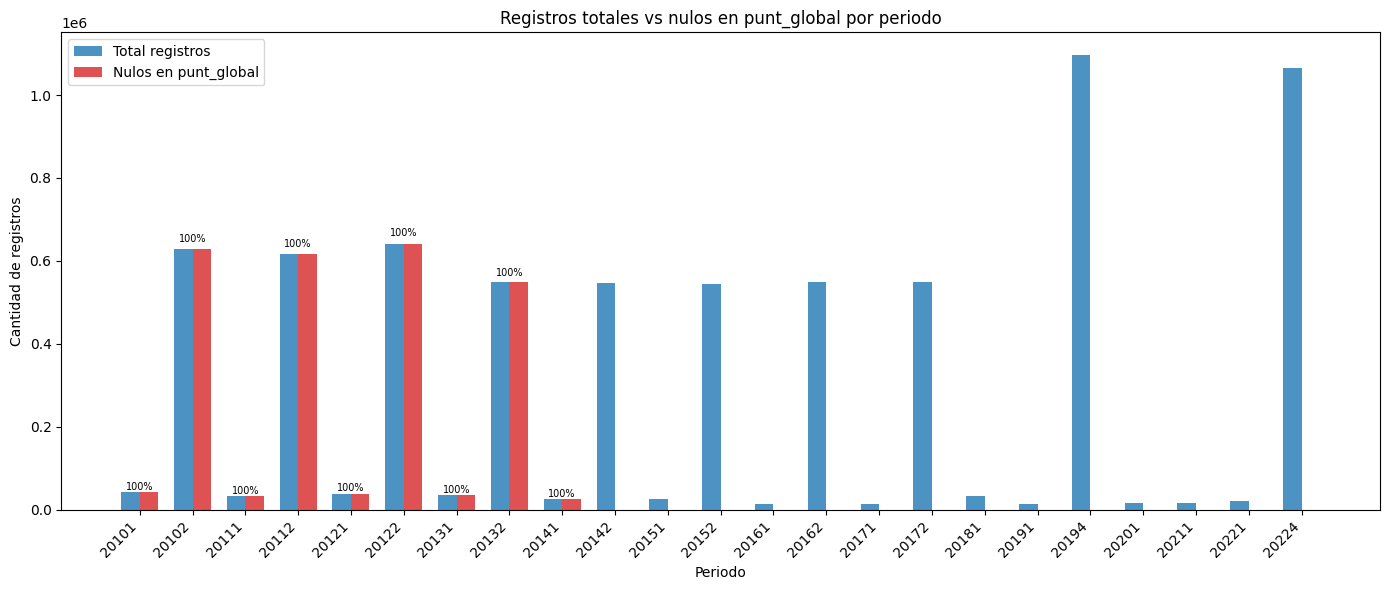

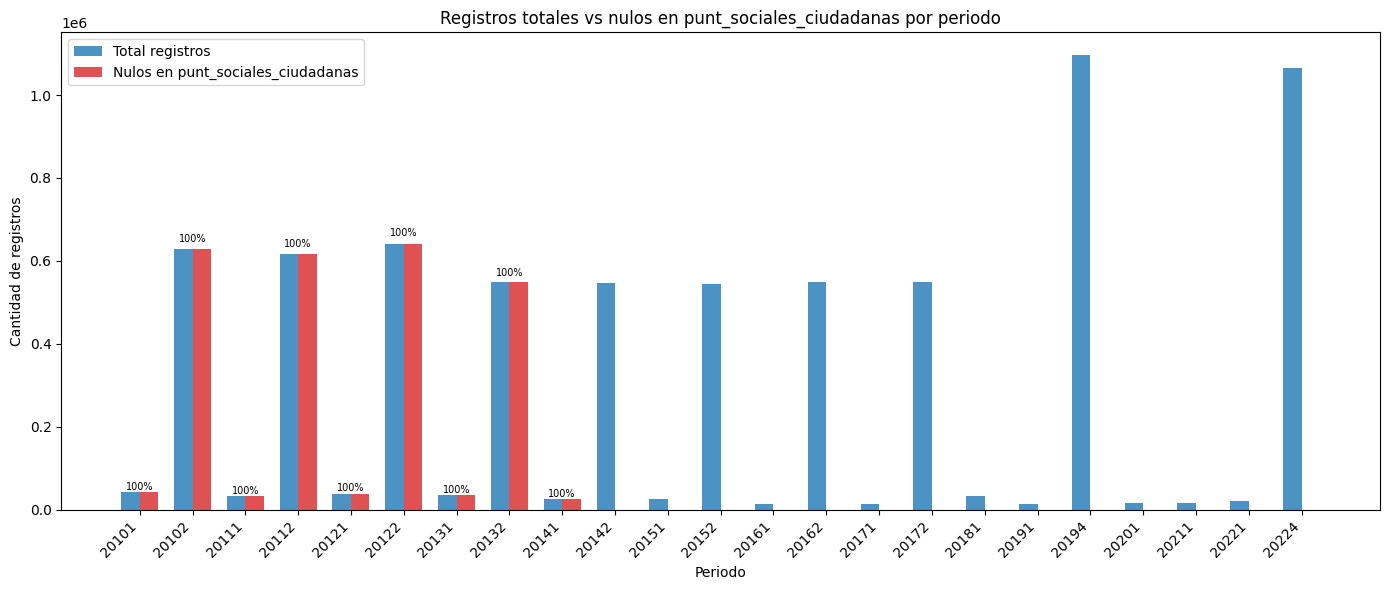

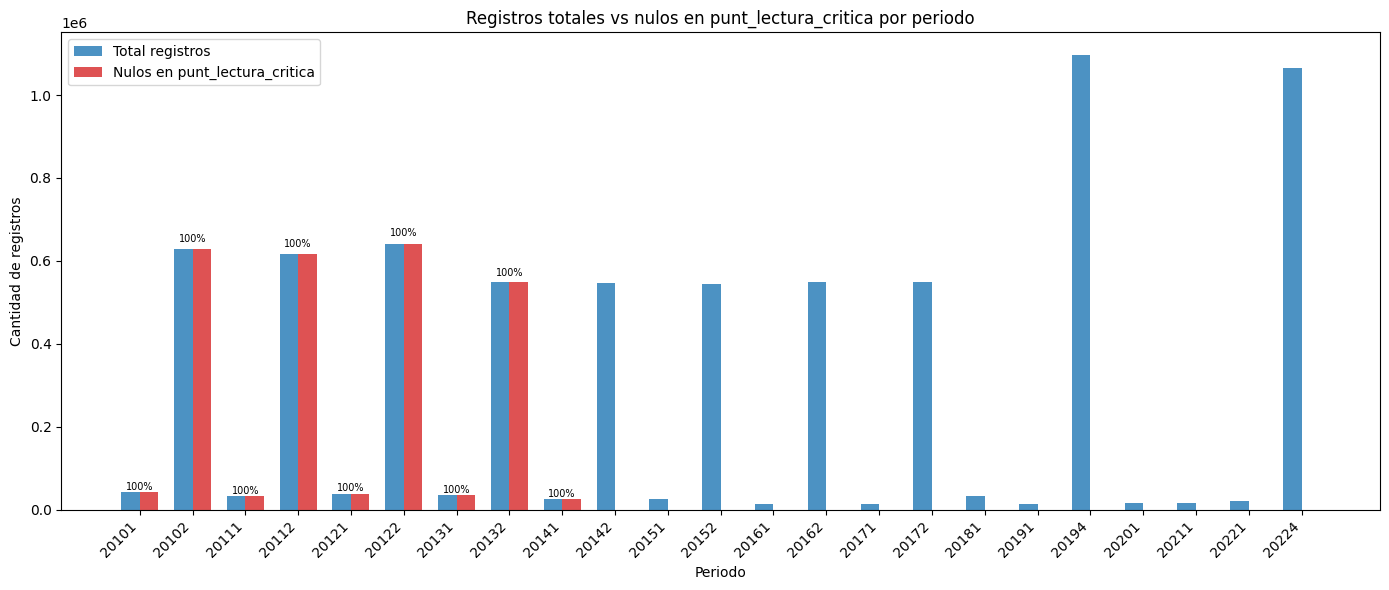

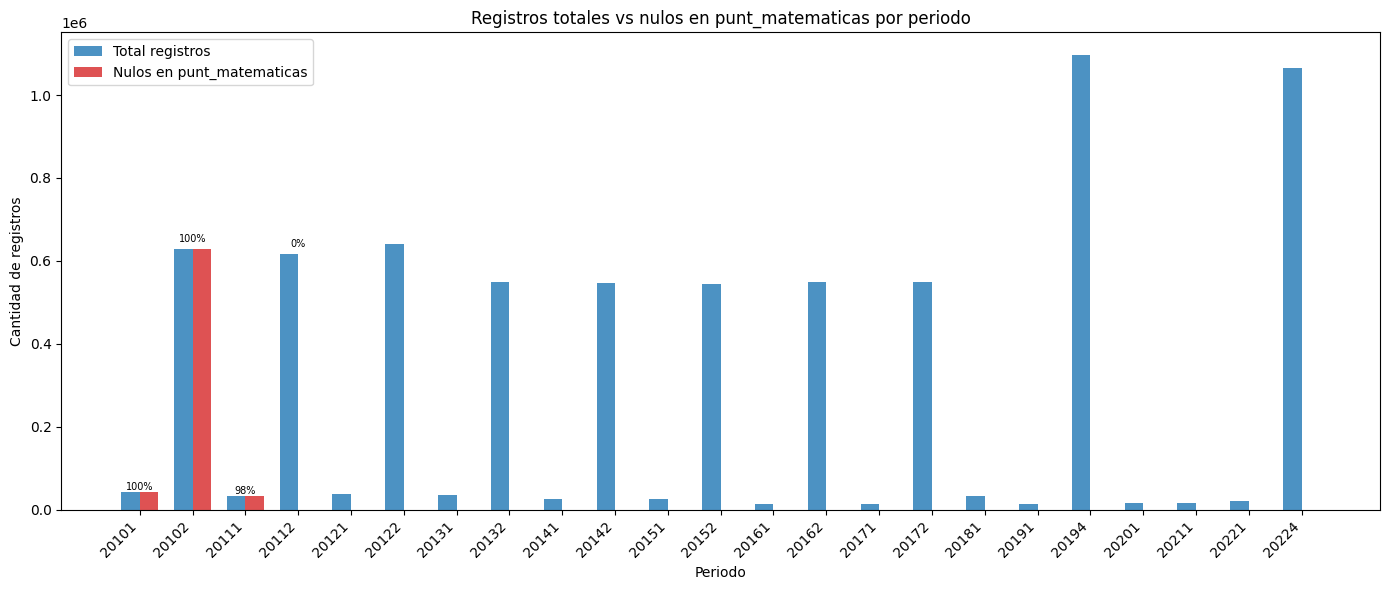

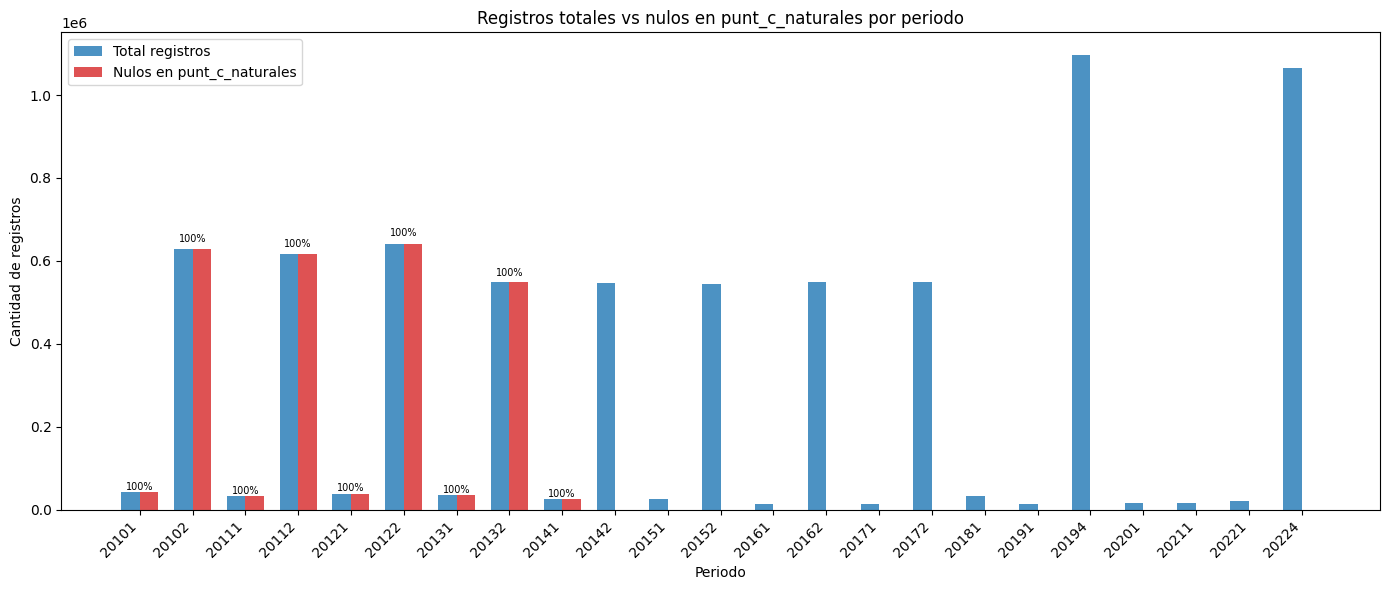

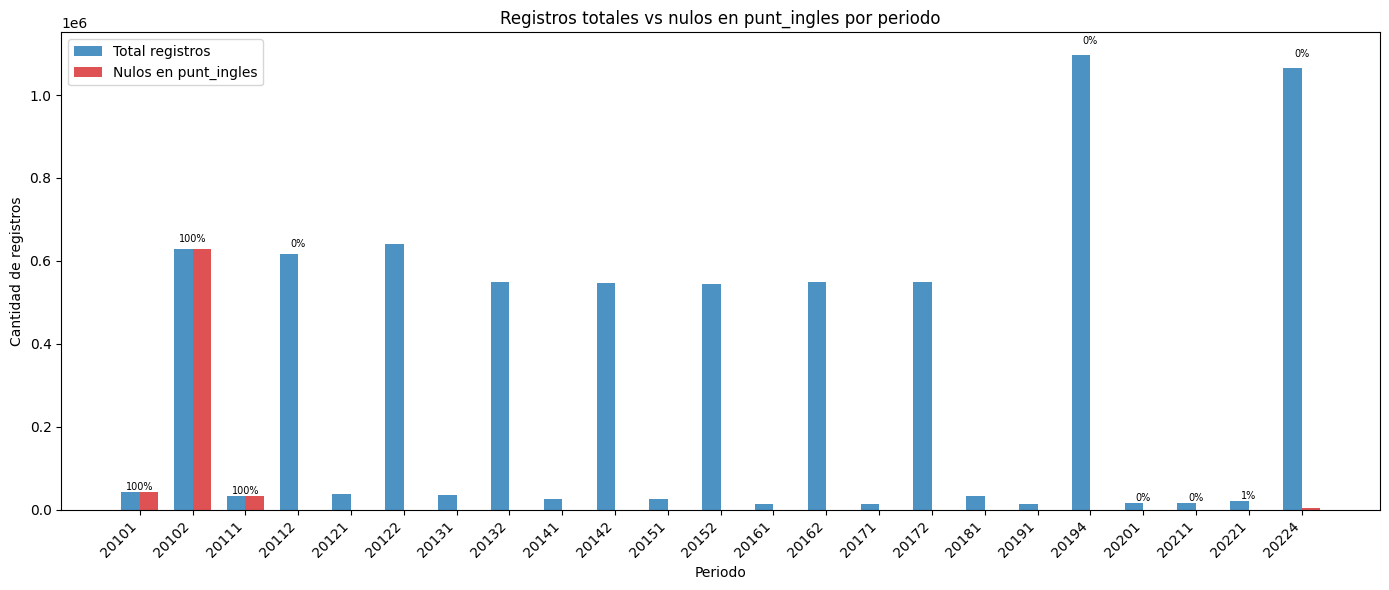

In [9]:
for col in cols_puntaje:
    plot_nulls_by_period(all_dataset, col, "periodo")

Para los períodos del 2010-1 al 2014-1 el 100% de los registros de los estudiantes, no tienen un puntaje global. De manera que tomaremos los registros desde el 2014-2.

In [10]:
all_dataset = all_dataset.filter(pl.col('punt_global').is_not_null())

print(f"Dataset después de eliminar filas con 'punt_global' nulo: {all_dataset.shape[0]:,} filas restantes")

Dataset después de eliminar filas con 'punt_global' nulo: 4,500,181 filas restantes


#### 4.3 Duplicados

**Hallazgo:** Registros duplicados exactos detectados por `estu_consecutivo`.

**Decisión:** Eliminar duplicados exactos, conservar el primero.

In [11]:
from eda_utils import detect_duplicates

In [12]:
_ = detect_duplicates(all_dataset)
_ = detect_duplicates(all_dataset, subset=['estu_consecutivo'])

2026-04-26 22:07:50.592 | INFO     | eda_utils:detect_duplicates:84 - Duplicados exactos: 2,204,265 (48.98%)
2026-04-26 22:07:50.701 | INFO     | eda_utils:detect_duplicates:81 - Duplicados por ['estu_consecutivo']: 2,204,265 (48.98%)


In [13]:
all_dataset = all_dataset.with_columns(
    pl.col('estu_consecutivo')
    .cum_count()
    .over('estu_consecutivo')
    .alias('duplicate_count')
)

In [14]:
estudiantes_duplicados = all_dataset.filter(pl.col('duplicate_count') > 1).select(['estu_consecutivo']).unique()['estu_consecutivo'].to_list()

dataset_duplicados = all_dataset.filter(pl.col('estu_consecutivo').is_in(estudiantes_duplicados)).sort(['estu_consecutivo', 'duplicate_count'], descending=True)
dataset_duplicados.filter(pl.col('duplicate_count') == dataset_duplicados.select(pl.col('duplicate_count').max()).item()).show()

cole_nombre_establecimiento,punt_ingles,estu_cod_depto_presentacion,cole_sede_principal,punt_matematicas,estu_cod_reside_mcpio,cole_caracter,fami_cuartoshogar,desemp_ingles,fami_educacionpadre,estu_tipodocumento,estu_fechanacimiento,estu_estadoinvestigacion,estu_cod_reside_depto,fami_tienecomputador,estu_genero,cole_cod_dane_sede,punt_lectura_critica,fami_tienelavadora,fami_personashogar,estu_depto_presentacion,cole_cod_depto_ubicacion,estu_cod_mcpio_presentacion,estu_depto_reside,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_naturaleza,punt_sociales_ciudadanas,cole_calendario,estu_mcpio_reside,periodo,cole_genero,fami_estratovivienda,cole_area_ubicacion,cole_cod_dane_establecimiento,cole_nombre_sede,estu_privado_libertad,cole_bilingue,cole_mcpio_ubicacion,punt_c_naturales,estu_mcpio_presentacion,fami_educacionmadre,estu_consecutivo,fami_tieneautomovil,estu_nacionalidad,cole_jornada,estu_pais_reside,punt_global,fami_tieneinternet,cole_depto_ubicacion,estu_estudiante,duplicate_count
str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,i64,str,str,str,u32
"""I.E. JOSE ANTONIO GALAN""",39,"""15""","""S""",50,"""15572""","""ACADÉMICO""","""Tres""","""A-""","""Secundaria (Bachillerato) comp…","""CC""","""07/05/2004""","""PUBLICAR""","""15""","""Si""","""M""","""115572000321""",51,"""Si""","""3 a 4""","""BOYACA""","""15""","""15572""","""BOYACA""","""15572""","""107078""","""OFICIAL""",45,"""A""","""PUERTO BOYACÁ""","""20224""","""MIXTO""","""Estrato 2""","""URBANO""","""115572000321""","""IE JOSE ANTONIO GALAN - SEDE P…","""N""","""N""","""PUERTO BOYACÁ""",52,"""PUERTO BOYACÁ""","""Secundaria (Bachillerato) inco…","""SB11202240479797""","""Si""","""COLOMBIA""","""TARDE""","""COLOMBIA""",243,"""Si""","""BOYACA""","""ESTUDIANTE""",4
"""I.E. JOSE ANTONIO GALAN""",35,"""15""","""S""",46,"""15572""","""ACADÉMICO""","""Dos""","""A-""","""Educación profesional completa""","""CC""","""30/03/2004""","""PUBLICAR""","""15""","""Si""","""M""","""115572000321""",51,"""Si""","""3 a 4""","""BOYACA""","""15""","""15572""","""BOYACA""","""15572""","""107078""","""OFICIAL""",49,"""A""","""PUERTO BOYACÁ""","""20224""","""MIXTO""","""Estrato 2""","""URBANO""","""115572000321""","""IE JOSE ANTONIO GALAN - SEDE P…","""N""","""N""","""PUERTO BOYACÁ""",56,"""PUERTO BOYACÁ""","""Educación profesional completa""","""SB11202240479634""","""No""","""COLOMBIA""","""TARDE""","""COLOMBIA""",247,"""Si""","""BOYACA""","""ESTUDIANTE""",4
"""I.E. JOSE ANTONIO GALAN""",41,"""15""","""S""",57,"""15572""","""ACADÉMICO""","""Tres""","""A-""","""Secundaria (Bachillerato) comp…","""CC""","""08/05/2004""","""PUBLICAR""","""15""","""Si""","""M""","""115572000321""",52,"""Si""","""3 a 4""","""BOYACA""","""15""","""15572""","""BOYACA""","""15572""","""107078""","""OFICIAL""",47,"""A""","""PUERTO BOYACÁ""","""20224""","""MIXTO""","""Estrato 3""","""URBANO""","""115572000321""","""IE JOSE ANTONIO GALAN - SEDE P…","""N""","""N""","""PUERTO BOYACÁ""",55,"""PUERTO BOYACÁ""","""Técnica o tecnológica incomple…","""SB11202240428102""","""No""","""COLOMBIA""","""TARDE""","""COLOMBIA""",259,"""Si""","""BOYACA""","""ESTUDIANTE""",4
"""I.E. JOSE ANTONIO GALAN""",44,"""15""","""S""",48,"""15572""","""ACADÉMICO""","""Tres""","""A-""","""No sabe""","""CC""","""06/04/2002""","""PUBLICAR""","""15""","""No""","""M""","""115572000321""",56,"""Si""","""3 a 4""","""BOYACA""","""15""","""15572""","""BOYACA""","""15572""","""107078""","""OFICIAL""",42,"""A""","""PUERTO BOYACÁ""","""20224""","""MIXTO""","""Estrato 2""","""URBANO""","""115572000321""","""IE JOSE ANTONIO GALAN - SEDE P…","""N""","""N""","""PUERTO BOYACÁ""",32,"""PUERTO BOYACÁ""","""Secundaria (Bachillerato) inco…","""SB11202240349257""","""No""","""COLOMBIA""","""TARDE""","""COLOMBIA""",222,"""Si""","""BOYACA""","""ESTUDIANTE""",4
"""I.E. JOSE ANTONIO GALAN""",56,"""15""","""S""",42,"""15572""","""AC

Excluiremos los registros con valores duplicados del análisis. En total, alrededor de 2.2 M duplicado. Hay estudiantes hasta 4 veces registrados en el mismo período, lo particular es que son del mismo colegio.

In [15]:
all_dataset = all_dataset.filter(pl.col('duplicate_count') == 1).drop('duplicate_count')
print(f"Dataset después de eliminar filas duplicadas: {all_dataset.shape[0]:,} filas restantes")

Dataset después de eliminar filas duplicadas: 3,395,834 filas restantes


#### 4.4 Variables de Baja Varianza

**Hallazgo:** Columnas con >99% un solo valor no aportan señal discriminante.

**Decisión:** Descartar columnas casi constantes.

In [16]:
from eda_utils import low_variance_columns, drop_columns

In [17]:
lv = low_variance_columns(all_dataset, threshold=99.0)
lv.filter(pl.col("drop") == True)

column,top_value,top_pct,drop
str,str,f64,bool
"""estu_estudiante""","""ESTUDIANTE""",100.0,true
"""estu_privado_libertad""","""N""",99.98,true
"""estu_estadoinvestigacion""","""PUBLICAR""",99.91,true
"""estu_nacionalidad""","""COLOMBIA""",99.7,true
"""estu_pais_reside""","""COLOMBIA""",99.7,true


In [18]:
cols_constantes = lv.filter(pl.col("drop") == True)['column'].to_list()
all_dataset = drop_columns(all_dataset, cols_constantes)

2026-04-26 22:08:03.938 | INFO     | eda_utils:drop_columns:103 - Eliminando 5 columnas: ['estu_estudiante', 'estu_privado_libertad', 'estu_estadoinvestigacion', 'estu_nacionalidad', 'estu_pais_reside']


---
### 5. Análisis del Target

#### 5.1 Distribución del Puntaje Global

In [19]:
from eda_utils import plot_target_distribution, numeric_profile

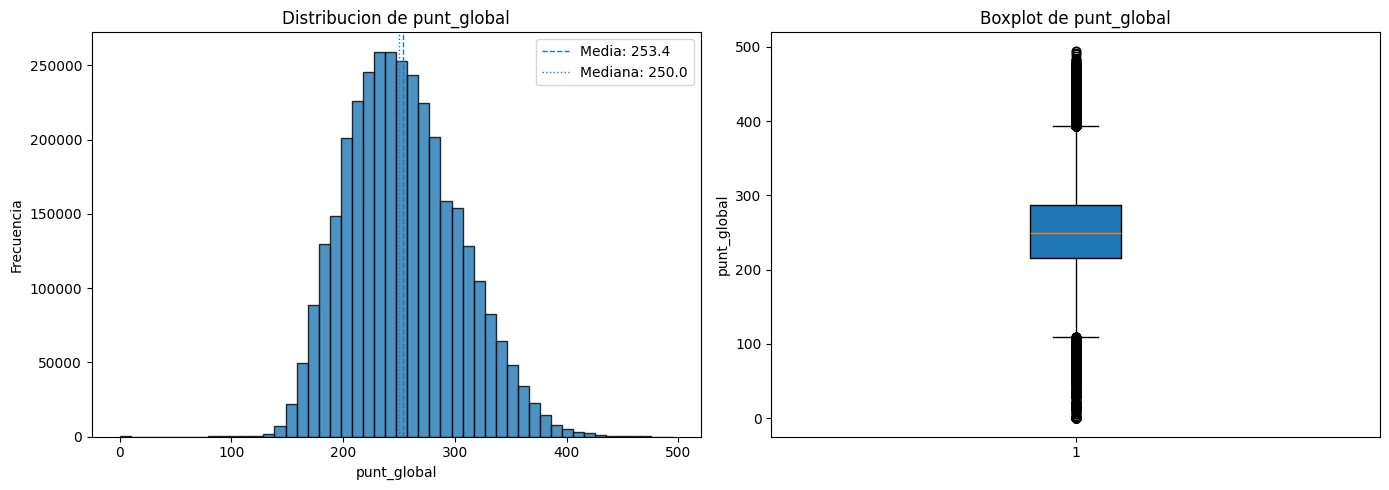

2026-04-26 22:08:04.198 | INFO     | eda_utils:plot_target_distribution:249 - punt_global | n=3,395,834 | media=253.4 | mediana=250.0 | std=49.8


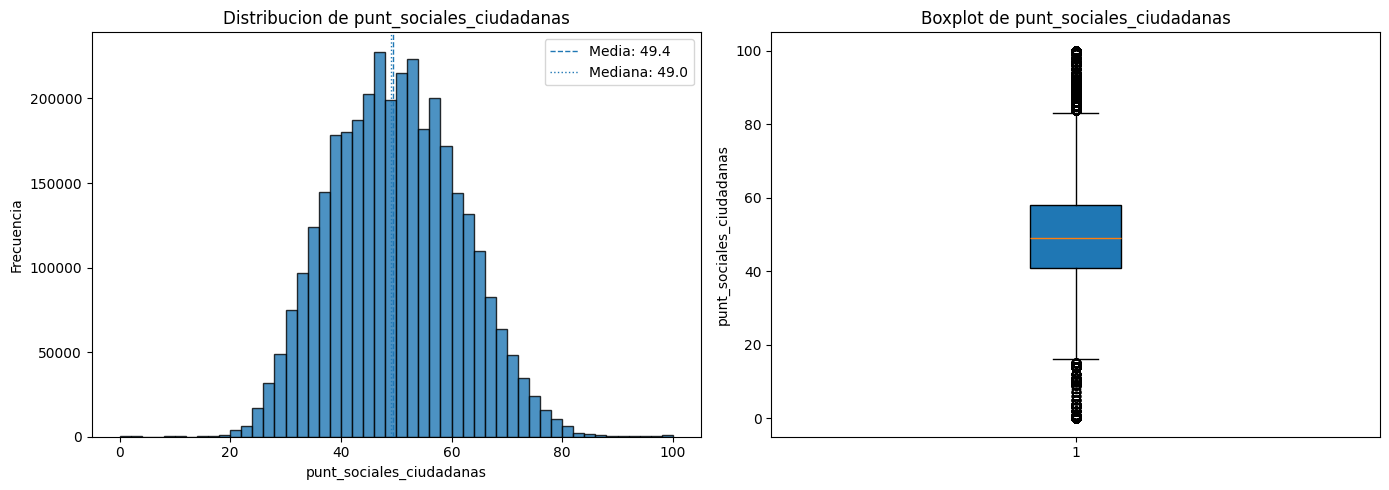

2026-04-26 22:08:04.452 | INFO     | eda_utils:plot_target_distribution:249 - punt_sociales_ciudadanas | n=3,395,834 | media=49.4 | mediana=49.0 | std=11.5


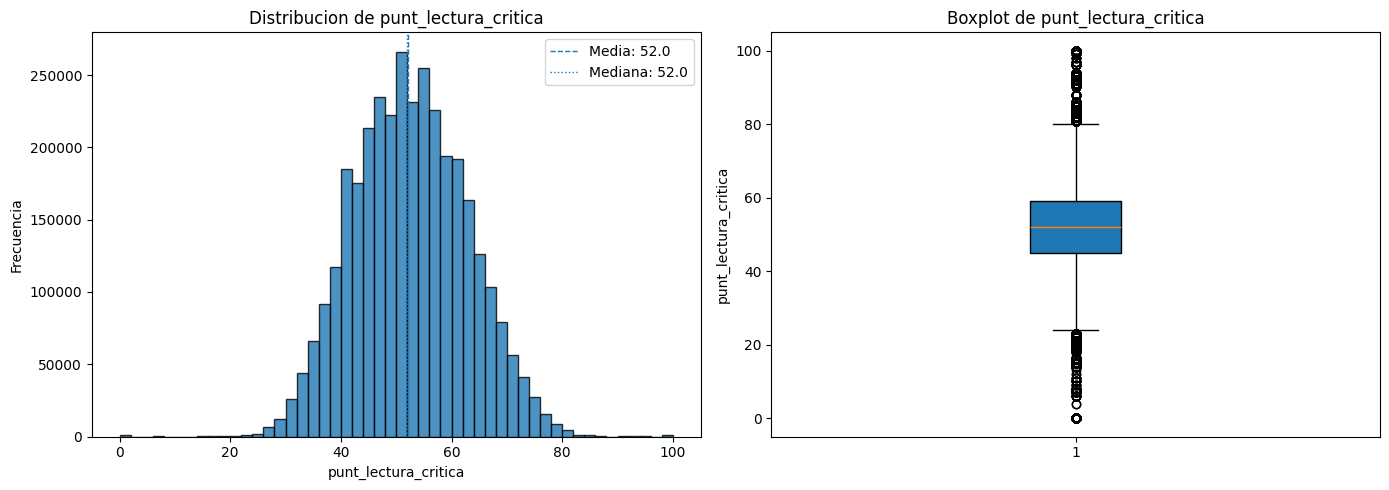

2026-04-26 22:08:04.686 | INFO     | eda_utils:plot_target_distribution:249 - punt_lectura_critica | n=3,395,834 | media=52.0 | mediana=52.0 | std=10.3


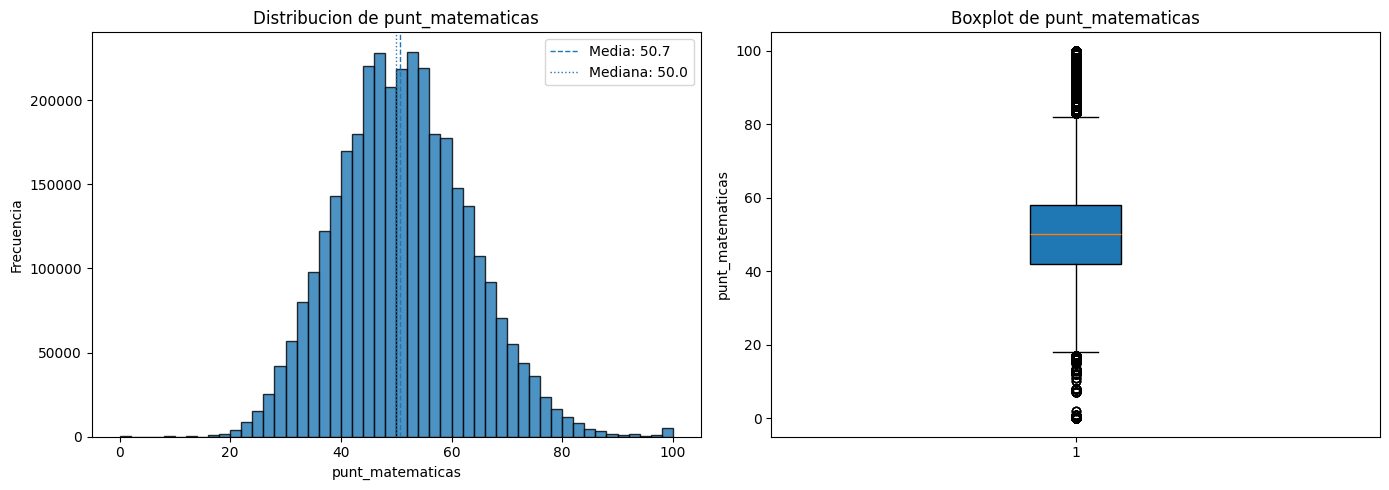

2026-04-26 22:08:04.900 | INFO     | eda_utils:plot_target_distribution:249 - punt_matematicas | n=3,395,834 | media=50.7 | mediana=50.0 | std=12.0


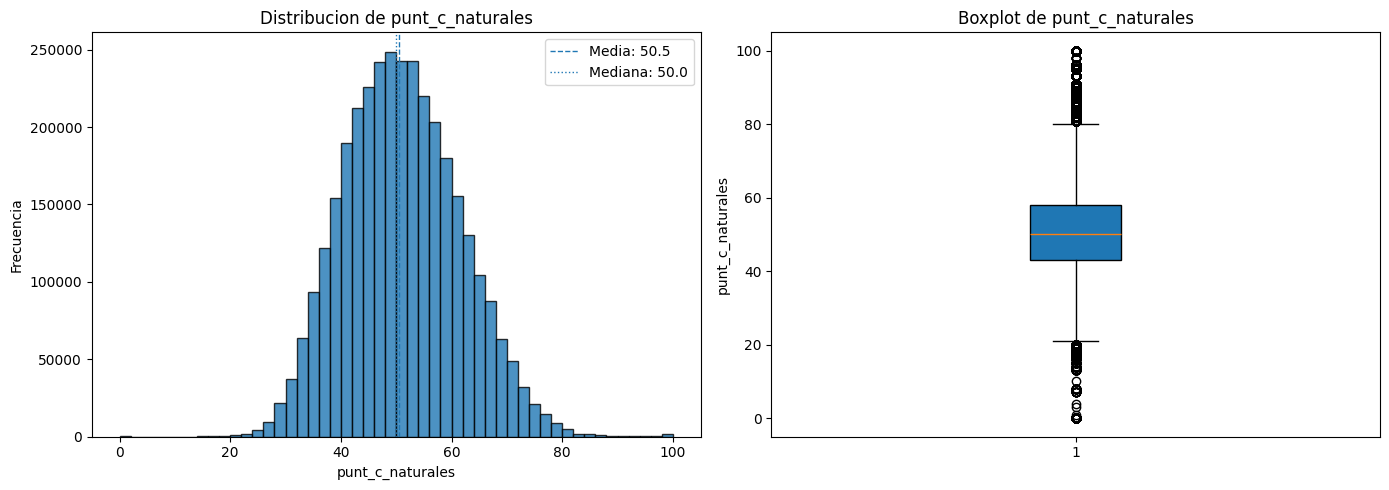

2026-04-26 22:08:05.150 | INFO     | eda_utils:plot_target_distribution:249 - punt_c_naturales | n=3,395,834 | media=50.5 | mediana=50.0 | std=10.5


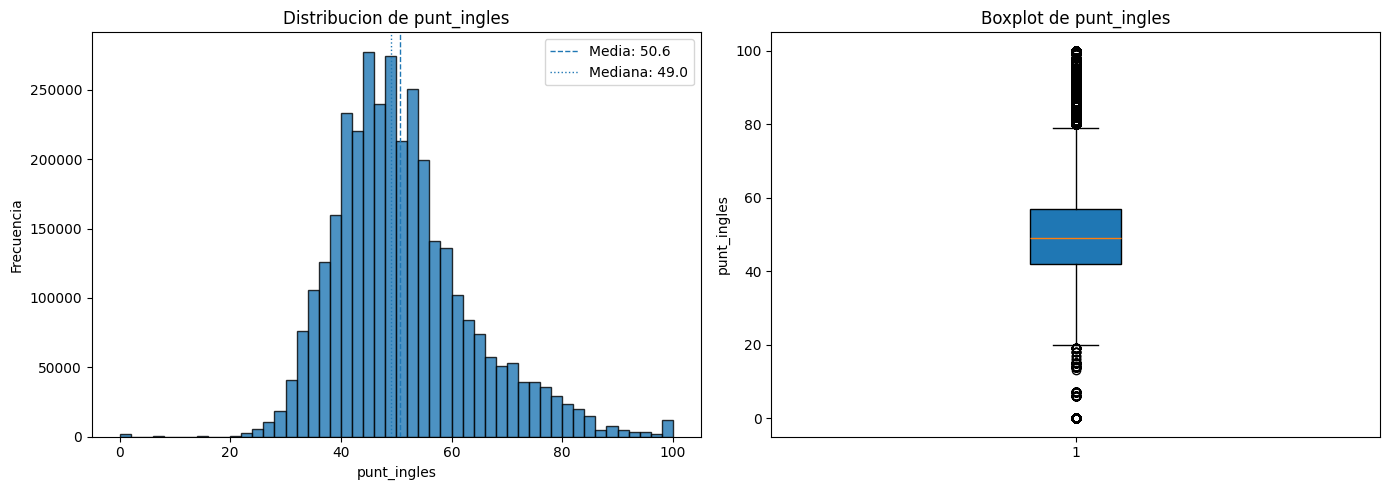

2026-04-26 22:08:05.420 | INFO     | eda_utils:plot_target_distribution:249 - punt_ingles | n=3,393,651 | media=50.6 | mediana=49.0 | std=12.4


In [20]:
for col in cols_puntaje:
    plot_target_distribution(all_dataset, col)

In [21]:
numeric_profile(all_dataset, ['punt_global'])

column,count,mean,median,std,min,q1,q3,max,skew,kurtosis,outlier_pct_iqr
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""punt_global""",3395834,253.38,250.0,49.83,0.0,216.0,287.0,495.0,0.362,-0.142,0.44


---
### 6. EDA Univariado y Bivariado

#### 6.1 Variables Socioeconómicas vs Target

Hipótesis central del proyecto: las condiciones socioeconómicas predicen el desempeño.

In [22]:
from eda_utils import plot_categorical_vs_target

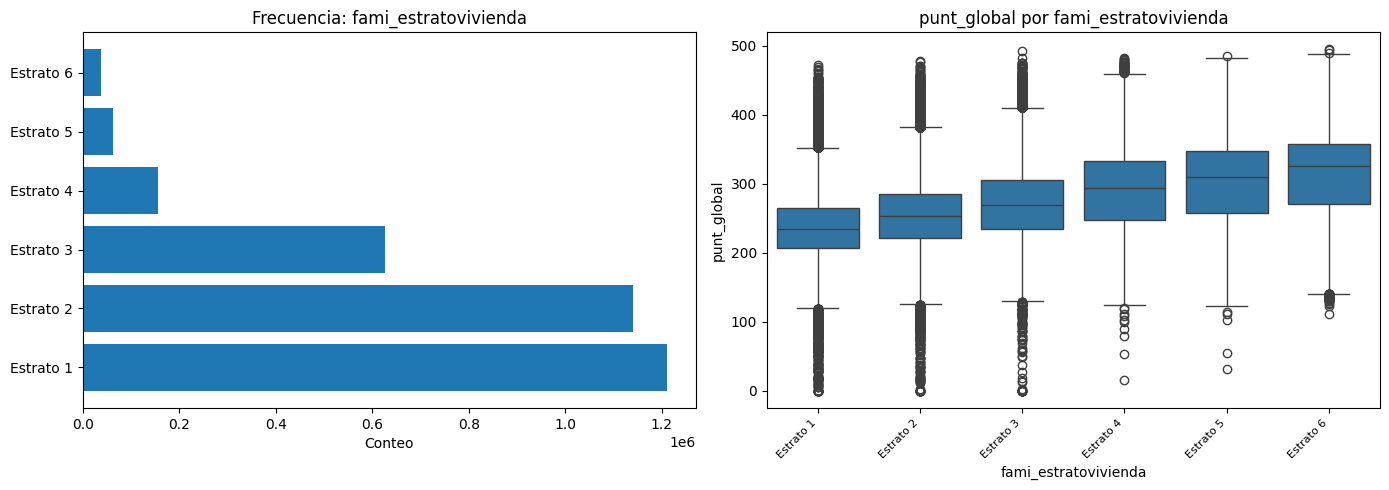

In [23]:
# Estrato
orden_estrato = [
    "Estrato 1", 
    "Estrato 2",
    "Estrato 3",
    "Estrato 4",
    "Estrato 5",
    "Estrato 6"
]

plot_categorical_vs_target(
    all_dataset,
    "fami_estratovivienda",
    "punt_global",
    order=orden_estrato,
    max_label_len=20
)

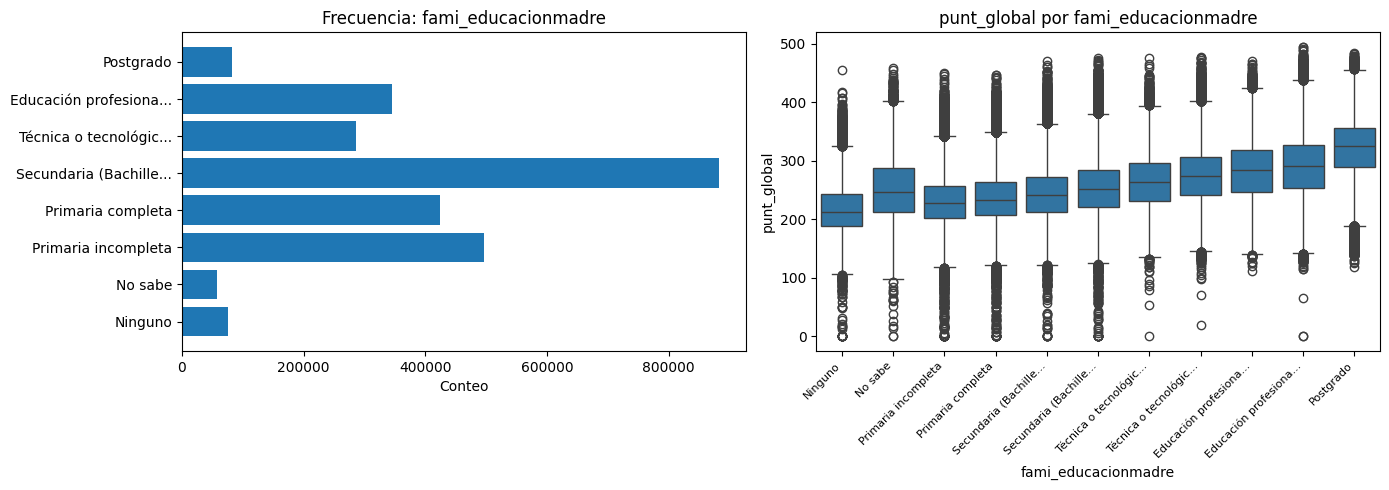

In [24]:
orden_educacion = [
    'Ninguno',
    'No sabe',
    'Primaria incompleta',
    'Primaria completa',
    'Secundaria (Bachillerato) incompleta',
    'Secundaria (Bachillerato) completa',
    'Técnica o tecnológica incompleta',
    'Técnica o tecnológica completa',
    'Educación profesional incompleta',
    'Educación profesional completa',
    'Postgrado',
]

# Educación de la madre
plot_categorical_vs_target(all_dataset, "fami_educacionmadre", "punt_global", order=orden_educacion)

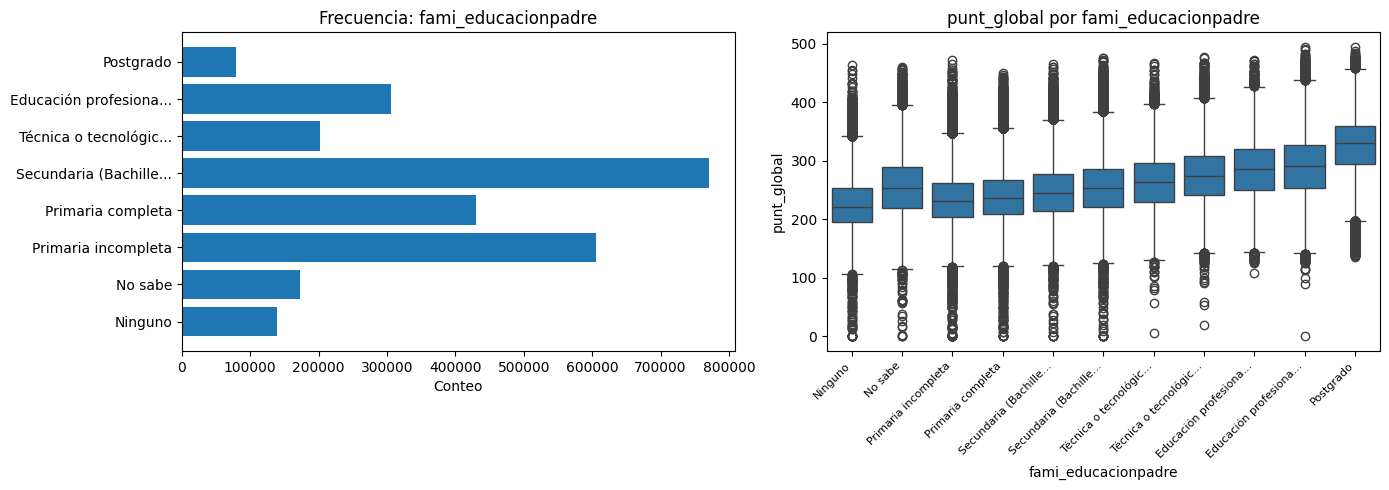

In [25]:
# Educación del padre
plot_categorical_vs_target(all_dataset, "fami_educacionpadre", "punt_global", order=orden_educacion)

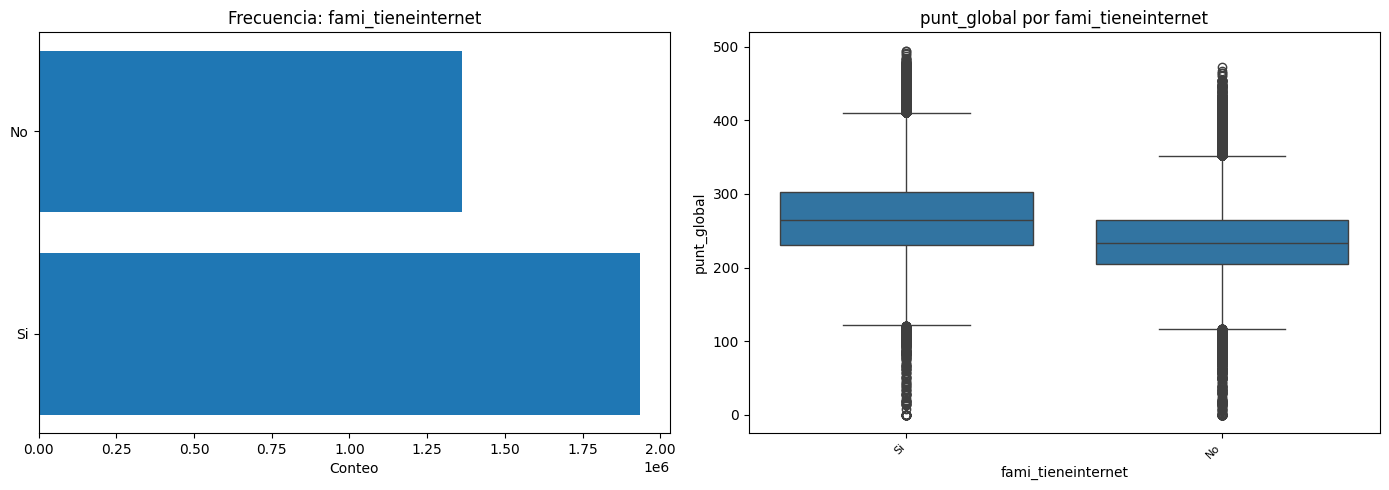

In [26]:
# Brecha Digital - Internet en casa
plot_categorical_vs_target(all_dataset, "fami_tieneinternet", "punt_global")

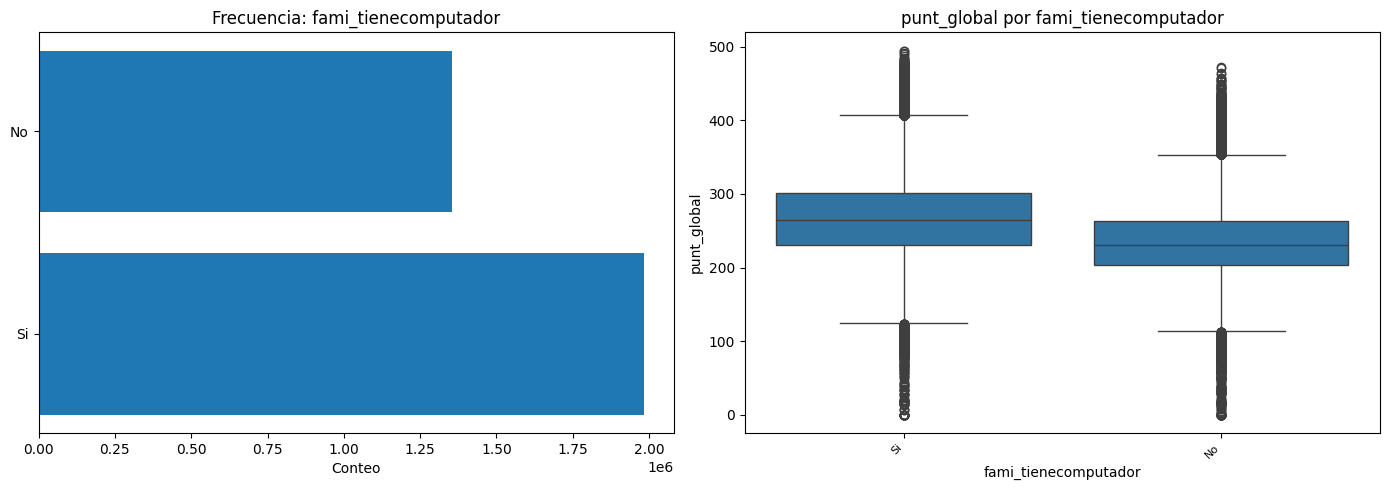

In [27]:
# Brecha Digital - Computador en casa
plot_categorical_vs_target(all_dataset, "fami_tienecomputador", "punt_global")

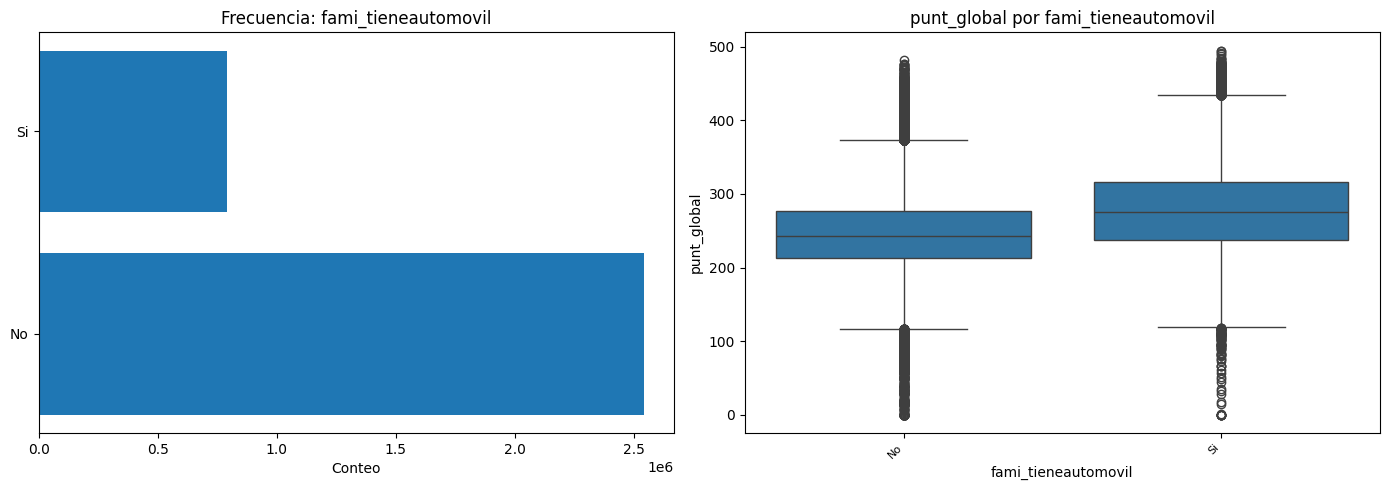

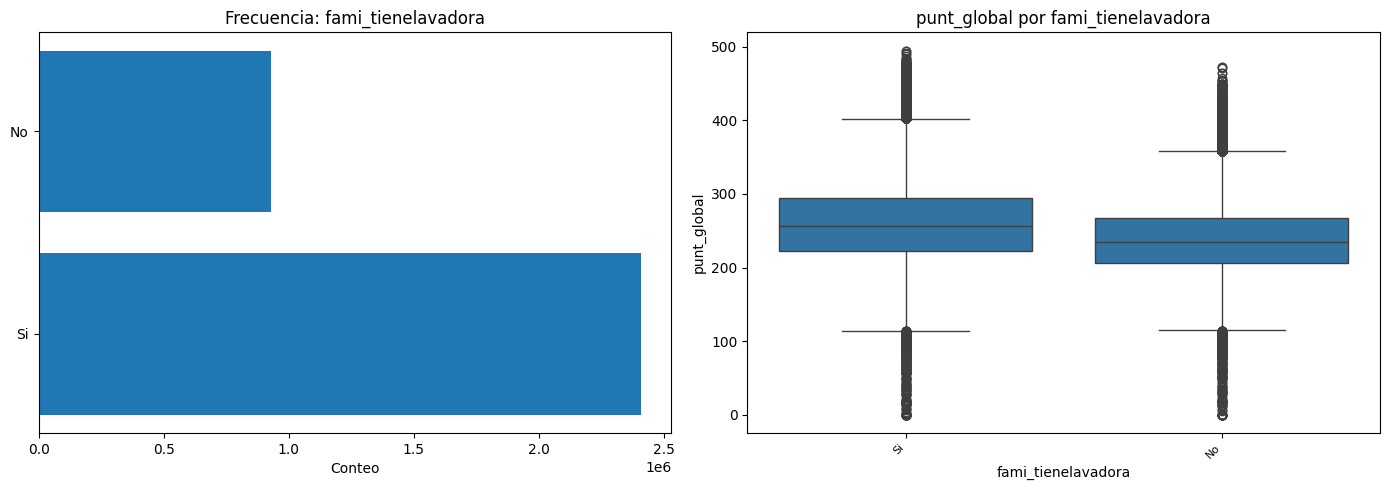

In [28]:
# Proxies de ingreso
for col in ["fami_tieneautomovil", "fami_tienelavadora"]:
    plot_categorical_vs_target(all_dataset, col, "punt_global")

#### 6.2 Variables del Colegio vs Target

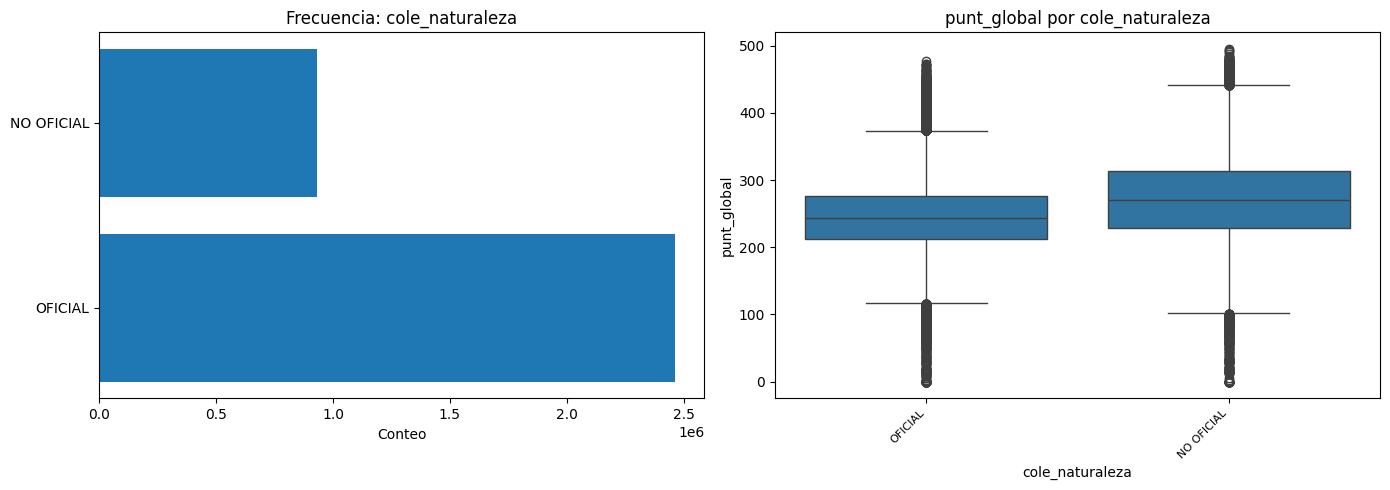

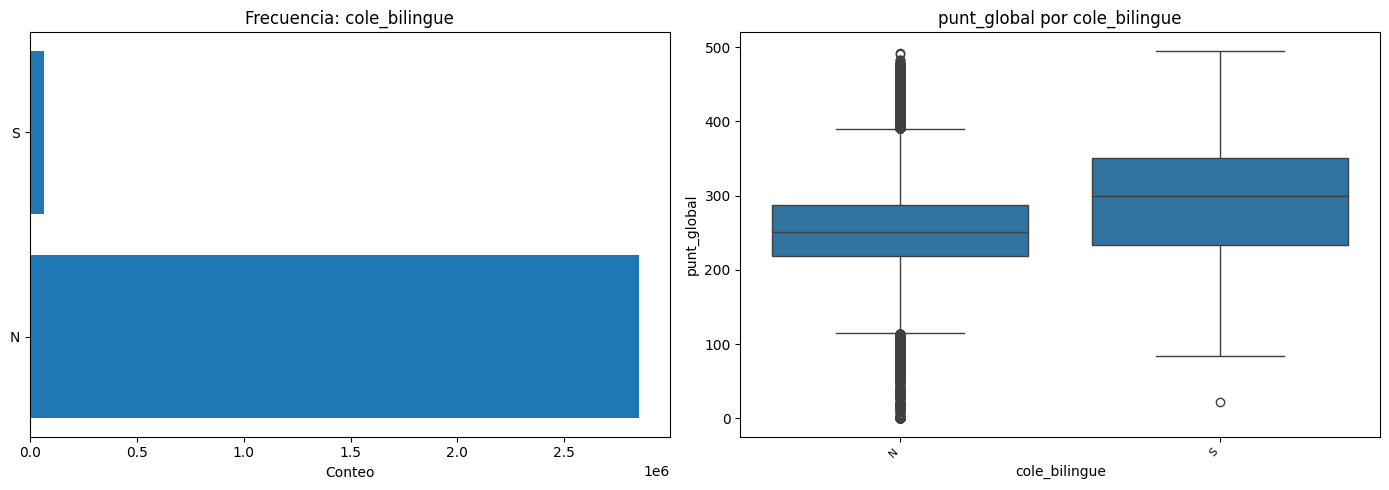

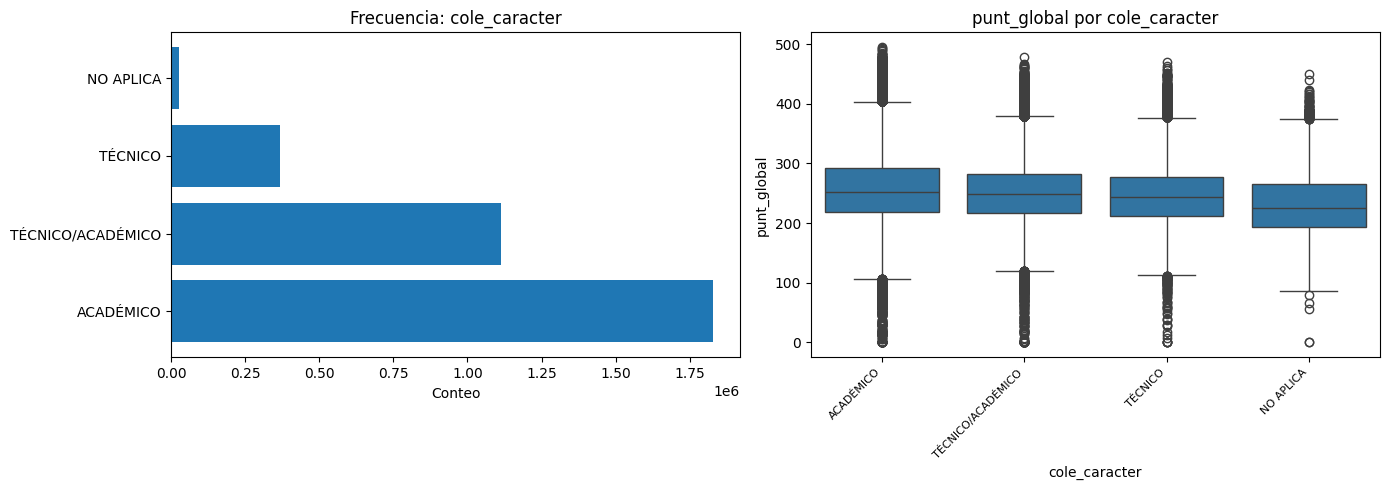

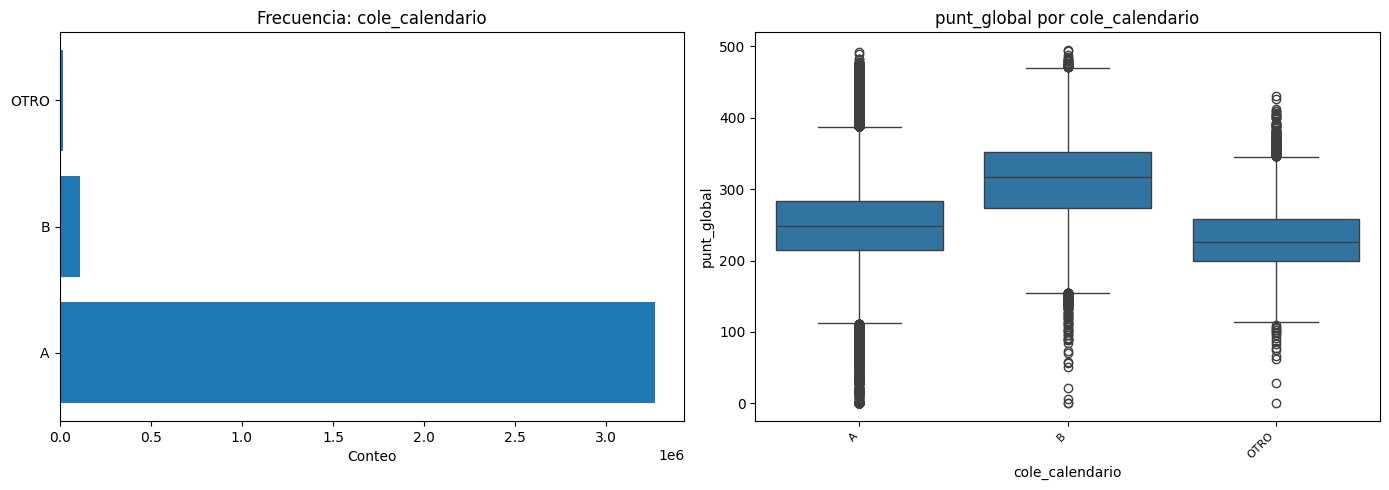

In [29]:
for col in ["cole_naturaleza", "cole_bilingue", "cole_caracter", "cole_calendario"]:
    plot_categorical_vs_target(all_dataset, col, "punt_global")

#### 6.3 Asociación de Features con el Target (Correlation Ratio)

El **correlation ratio (eta)** mide la asociación entre una variable categórica y una numérica. Equivale al R² de un ANOVA de una vía. Rango: 0 (sin asociación) a 1 (asociación perfecta).

In [30]:
from eda_utils import feature_target_association, plot_feature_target_association

cat_features = [
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_tieneinternet",
    "fami_tienecomputador",
    "fami_tieneautomovil",
    "fami_tienelavadora",
    "fami_personashogar",
    "fami_cuartoshogar",
    "cole_naturaleza",
    "cole_area_ubicacion",
    "cole_calendario",
    "cole_jornada", 
    "cole_bilingue",
    "cole_genero",
    "cole_caracter",
    "estu_genero", 
    "desemp_ingles",
]

# Tabla de asociacion
assoc = feature_target_association(all_dataset, cat_features, "punt_global")
assoc

feature,eta
str,f64
"""desemp_ingles""",0.5552
"""fami_educacionmadre""",0.1822
"""fami_educacionpadre""",0.1659
"""cole_jornada""",0.1421
"""fami_estratovivienda""",0.1247
…,…
"""cole_area_ubicacion""",0.0217
"""cole_bilingue""",0.0132
"""fami_cuartoshogar""",0.0104


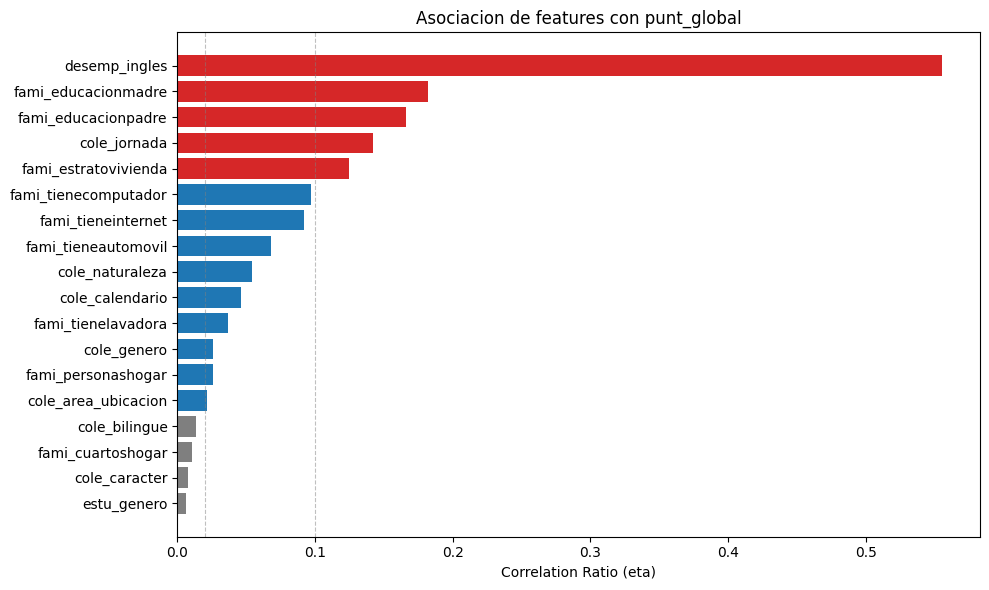

2026-04-26 22:08:26.785 | INFO     | eda_utils:plot_feature_target_association:780 -   desemp_ingles: eta=0.5552
2026-04-26 22:08:26.786 | INFO     | eda_utils:plot_feature_target_association:780 -   fami_educacionmadre: eta=0.1822
2026-04-26 22:08:26.786 | INFO     | eda_utils:plot_feature_target_association:780 -   fami_educacionpadre: eta=0.1659
2026-04-26 22:08:26.786 | INFO     | eda_utils:plot_feature_target_association:780 -   cole_jornada: eta=0.1421
2026-04-26 22:08:26.787 | INFO     | eda_utils:plot_feature_target_association:780 -   fami_estratovivienda: eta=0.1247


In [31]:
plot_feature_target_association(all_dataset, cat_features, "punt_global")

#### 6.4 Análisis Temporal

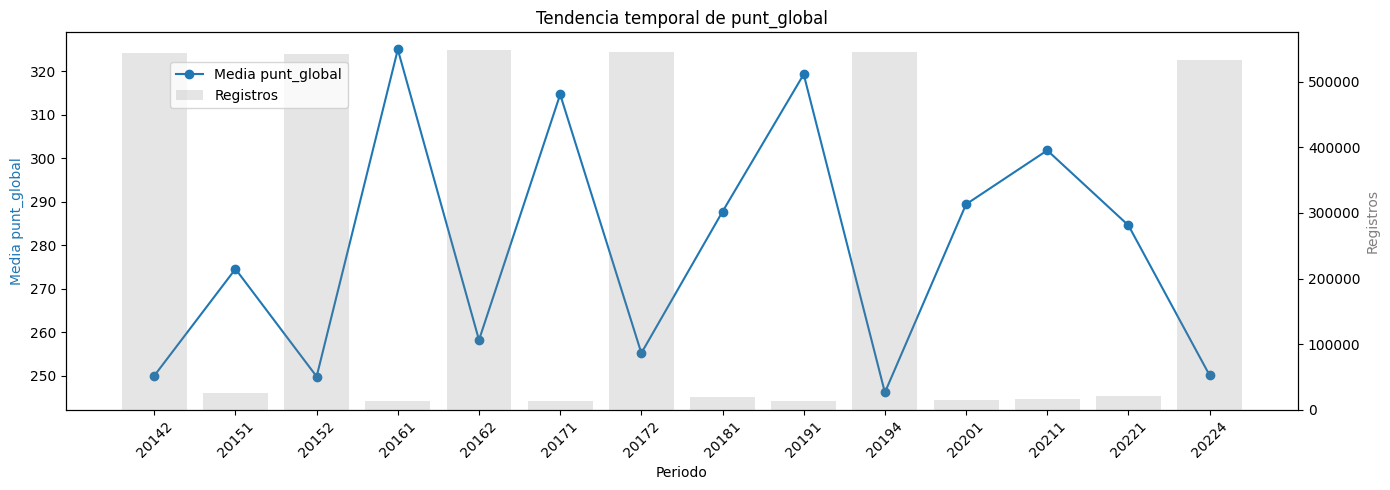

periodo,len
str,u32
"""20142""",544535
"""20151""",25947
"""20152""",542450
"""20161""",13064
"""20162""",548206
…,…
"""20194""",546211
"""20201""",15435
"""20211""",15528


In [32]:
from eda_utils import plot_temporal_trend

plot_temporal_trend(all_dataset, "punt_global", "periodo")

# Conteo de registros por periodo
all_dataset.group_by("periodo").len().sort("periodo")

#### 6.5 Análisis Geográfico

In [33]:
# Top y bottom departamentos
depto_stats = (
    all_dataset.group_by("estu_depto_reside")
    .agg([
        pl.col("punt_global").cast(pl.Float64).mean().alias("mean_score"),
        pl.len().alias("n"),
    ])
    .sort("mean_score", descending=True)
)

In [34]:
print("Top 10:")
depto_stats.head(10)

Top 10:


estu_depto_reside,mean_score,n
str,f64,u32
"""BOGOTÁ""",274.017428,556642
"""SANTANDER""",265.110948,157118
"""BOYACA""",264.545622,100401
"""CUNDINAMARCA""",258.962437,218327
"""NORTE SANTANDER""",257.124209,94639
"""RISARALDA""",257.09029,64215
"""VALLE""",256.254401,295376
"""QUINDIO""",255.404124,41074
"""META""",254.055129,71741


In [35]:
print("Bottom 10:")
depto_stats.tail(10)

Bottom 10:


estu_depto_reside,mean_score,n
str,f64,u32
"""EXTRANJERO""",235.496454,141
"""BOLIVAR""",234.722955,153495
"""GUAINIA""",233.939914,1631
"""GUAVIARE""",233.223129,5759
"""VICHADA""",230.944816,2990
"""MAGDALENA""",228.325423,95826
"""LA GUAJIRA""",226.893186,48477
"""AMAZONAS""",221.588882,4911
"""VAUPES""",218.033808,2248


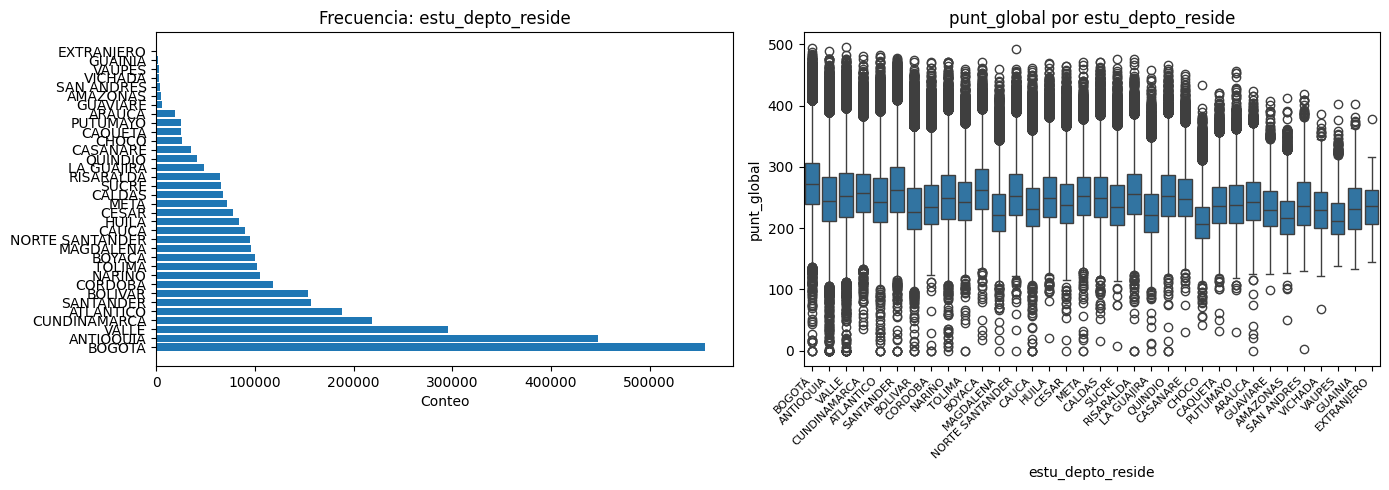

In [36]:
plot_categorical_vs_target(all_dataset, "estu_depto_reside", "punt_global")

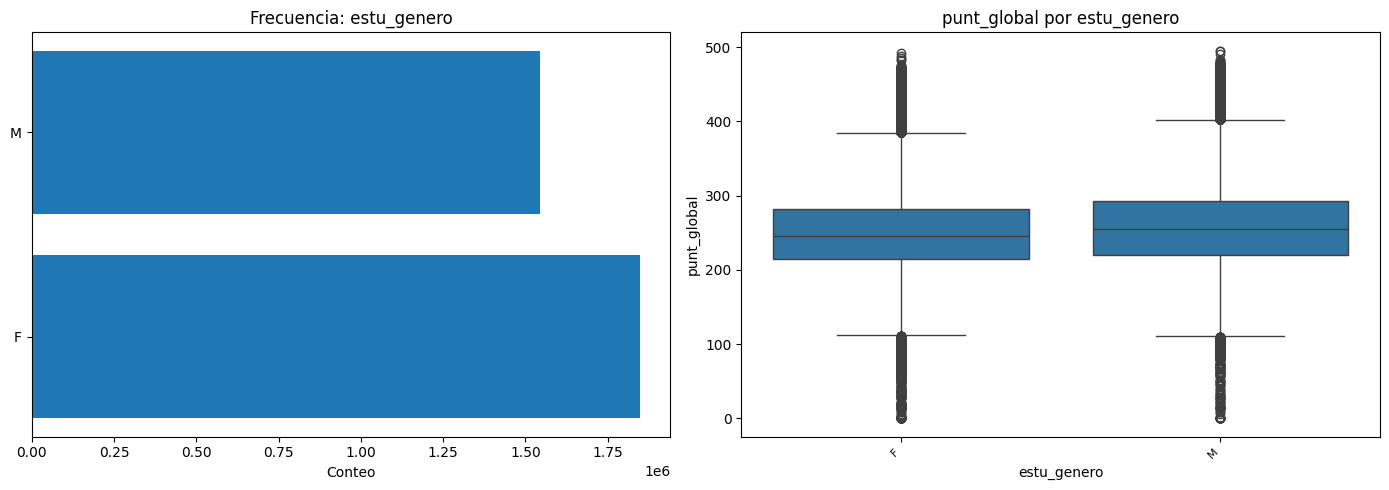

In [37]:
plot_categorical_vs_target(all_dataset, "estu_genero", "punt_global")

---
### 7. Análisis Avanzado

#### 7.1 Brechas de Equidad

Cuantificamos las brechas con Cohen's d (tamaño del efecto estandarizado). Interpretación: d < 0.2 pequeño, 0.2–0.8 medio, > 0.8 grande.

In [38]:
from eda_utils import equity_gap_table

brechas = [
    equity_gap_table(all_dataset, "punt_global", "fami_estratovivienda", "Estrato 6", "Estrato 1"),
    equity_gap_table(all_dataset, "punt_global", "estu_genero", "M", "F"),
    equity_gap_table(all_dataset, "punt_global", "cole_area_ubicacion", "URBANO", "RURAL"),
    equity_gap_table(all_dataset, "punt_global", "cole_naturaleza", "NO OFICIAL", "OFICIAL"),
    equity_gap_table(all_dataset, "punt_global", "fami_tieneinternet", "Si", "No"),
]

pl.DataFrame(brechas)

group_col,group_a,group_b,mean_a,mean_b,diff,cohens_d,n_a,n_b
str,str,str,f64,f64,f64,f64,i64,i64
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",309.95,237.96,71.99,1.669,38241,1210693
"""estu_genero""","""M""","""F""",257.81,249.71,8.1,0.163,1544164,1848585
"""cole_area_ubicacion""","""URBANO""","""RURAL""",256.45,235.87,20.58,0.418,2888833,506995
"""cole_naturaleza""","""NO OFICIAL""","""OFICIAL""",272.3,246.24,26.06,0.538,931105,2464728
"""fami_tieneinternet""","""Si""","""No""",266.76,236.22,30.55,0.646,1934213,1362764


In [39]:
brechas_temporales = []
for periodo in all_dataset["periodo"].unique().sort().to_list():
    sub = all_dataset.filter(pl.col("periodo") == periodo)
    gap = equity_gap_table(sub, "punt_global", "fami_estratovivienda", "Estrato 6", "Estrato 1")

    if gap:
        gap["periodo"] = periodo
        brechas_temporales.append(gap)

pl.DataFrame(brechas_temporales)

group_col,group_a,group_b,mean_a,mean_b,diff,cohens_d,n_a,n_b,periodo
str,str,str,f64,f64,f64,f64,i64,i64,str
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",313.94,233.38,80.56,2.26,2188,230869,"""20142"""
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",351.26,217.21,134.05,3.068,2856,3364,"""20151"""
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",321.93,232.75,89.18,2.252,1939,241263,"""20152"""
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",356.61,292.8,63.82,1.397,2738,215,"""20161"""
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",322.14,241.42,80.71,1.886,1961,248630,"""20162"""
…,…,…,…,…,…,…,…,…,…
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",248.42,236.0,12.42,0.268,3711,159977,"""20194"""
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",326.27,236.18,90.09,1.835,2134,794,"""20201"""
"""fami_estratovivienda""","""Estrato 6""","""Estrato 1""",335.34,245.5,89.84,1.976,2518,589,"""20211"""


#### Evolución temporal de la brecha socioeconómica

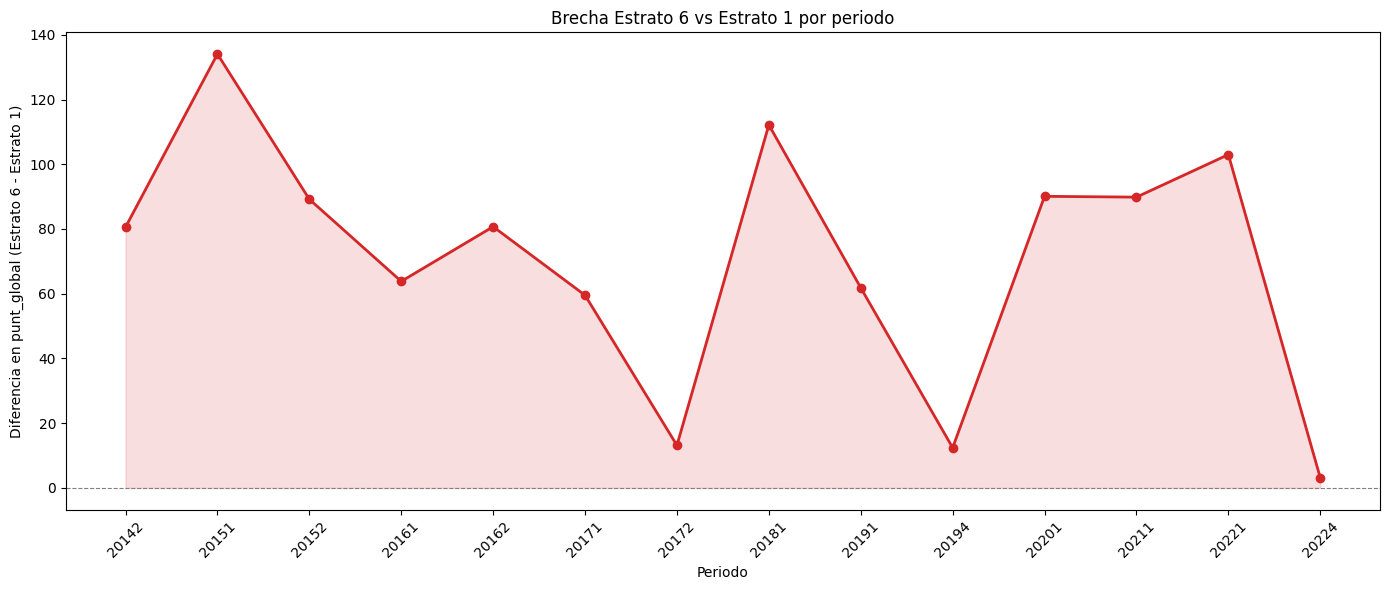

2026-04-26 22:08:34.002 | INFO     | eda_utils:plot_equity_gap_trend:663 - Brecha promedio: 71.0 | min: 3.1 (20224) | max: 134.1 (20151)


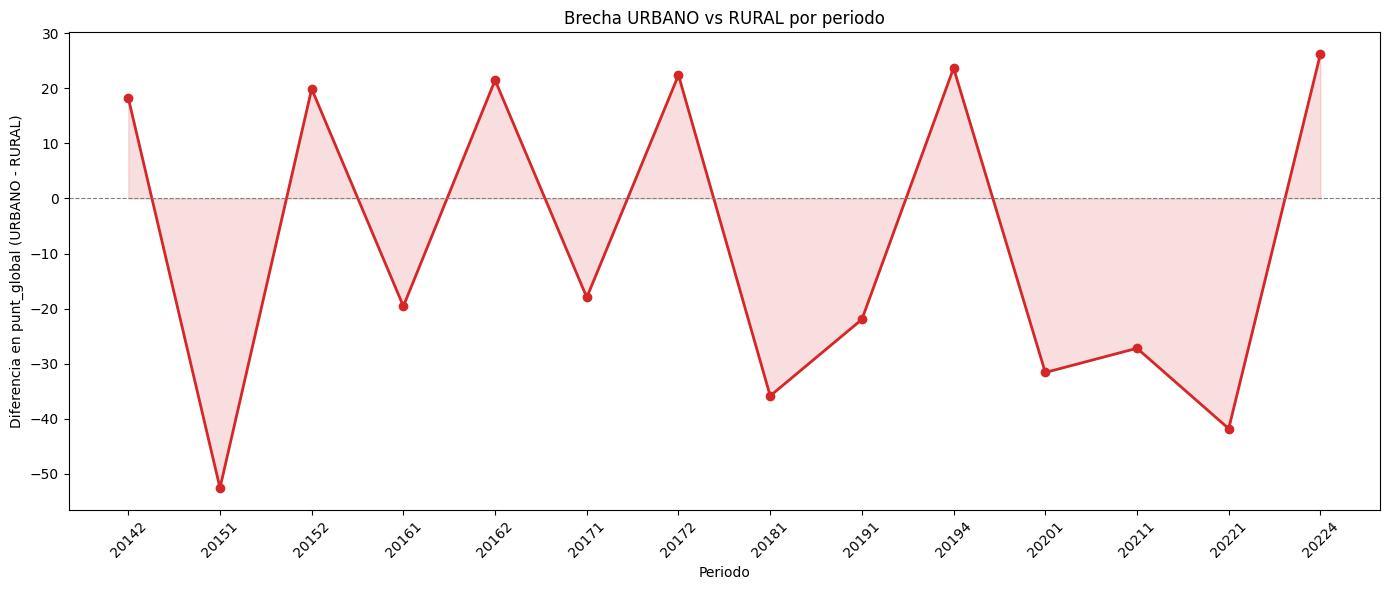

2026-04-26 22:08:34.998 | INFO     | eda_utils:plot_equity_gap_trend:663 - Brecha promedio: -8.3 | min: -52.6 (20151) | max: 26.2 (20224)


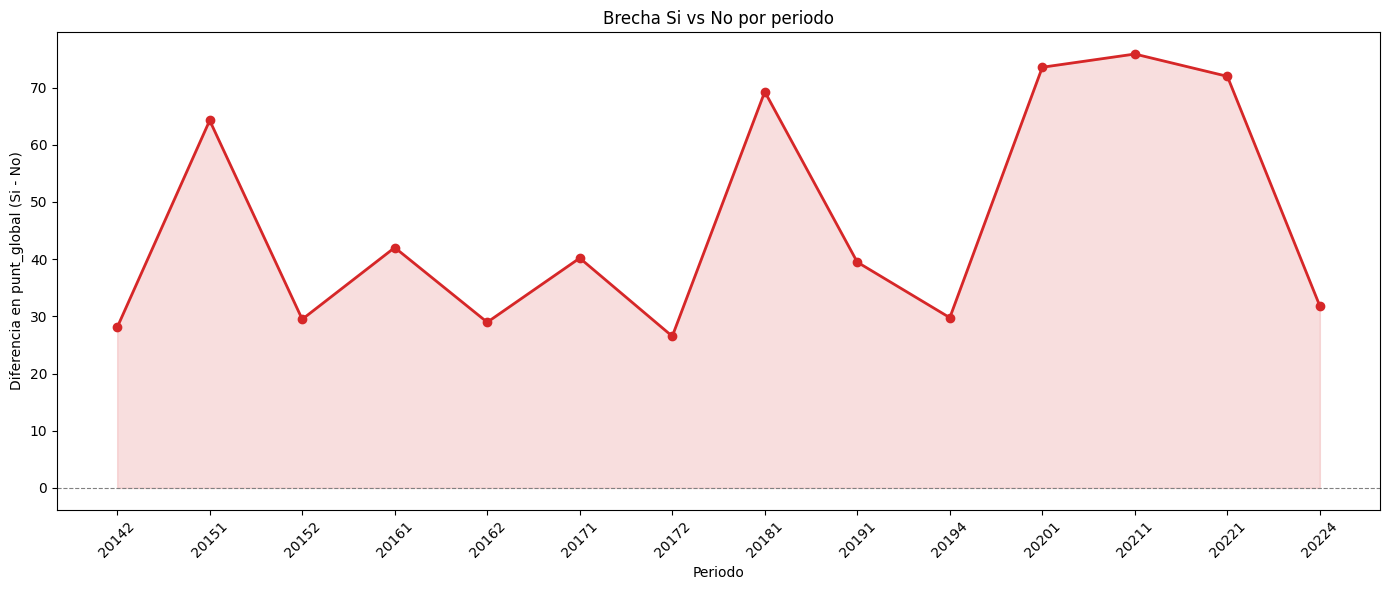

2026-04-26 22:08:35.737 | INFO     | eda_utils:plot_equity_gap_trend:663 - Brecha promedio: 46.5 | min: 26.5 (20172) | max: 75.9 (20211)


In [40]:
from eda_utils import plot_equity_gap_trend

plot_equity_gap_trend(
    all_dataset, "punt_global",
    "fami_estratovivienda", "Estrato 6", "Estrato 1",
)

plot_equity_gap_trend(
    all_dataset, "punt_global",
    "cole_area_ubicacion", "URBANO", "RURAL",
)

plot_equity_gap_trend(
    all_dataset, "punt_global",
    "fami_tieneinternet", "Si", "No",
)

#### 7.2 Interacciones y Efectos Confundidos

Las variables socioeconómicas están correlacionadas entre sí (estrato alto → internet → computador → padres con educación). Medimos la asociación entre categóricas con **Cramér's V** para detectar redundancia.

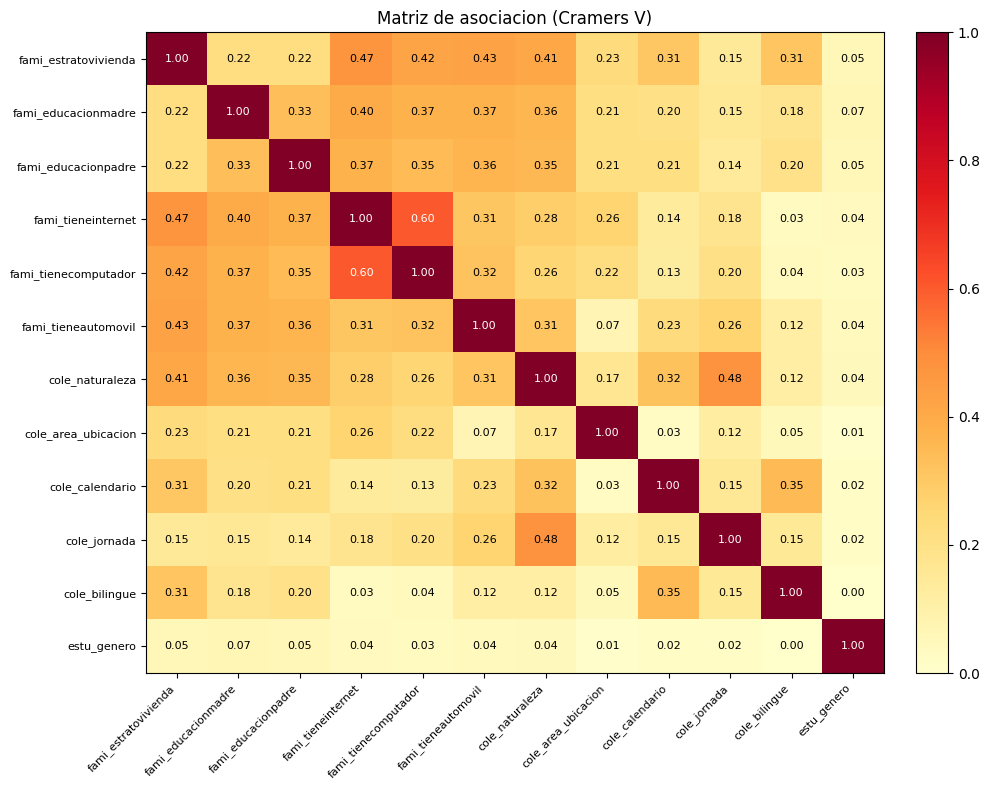

In [41]:
from eda_utils import plot_cramers_v_matrix

cat_features = [
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_tieneinternet",
    "fami_tienecomputador",
    "fami_tieneautomovil",
    "cole_naturaleza",
    "cole_area_ubicacion",
    "cole_calendario",
    "cole_jornada",
    "cole_bilingue",
    "estu_genero",
]

plot_cramers_v_matrix(all_dataset, cat_features)

In [42]:
# Tabla pivote: puntaje promedio por estrato x naturaleza del colegio
pivot = (
    all_dataset
    .filter(pl.col("punt_global").is_not_null())
    .group_by(["fami_estratovivienda", "cole_naturaleza"])
    .agg(pl.col("punt_global").cast(pl.Float64).mean().round(1).alias("mean_score"))
    .sort(["fami_estratovivienda", "cole_naturaleza"])
)
pivot

fami_estratovivienda,cole_naturaleza,mean_score
str,str,f64
null,null,192.0
null,"""NO OFICIAL""",239.1
null,"""OFICIAL""",224.9
"""Estrato 1""","""NO OFICIAL""",234.1
"""Estrato 1""","""OFICIAL""",238.5
…,…,…
"""Estrato 5""","""OFICIAL""",225.5
"""Estrato 6""","""NO OFICIAL""",329.7
"""Estrato 6""","""OFICIAL""",210.1


#### 7.3 Análisis Jerárquico (ICC por Colegio)

Los datos tienen estructura jerárquica: estudiantes anidados dentro de colegios. El **ICC** mide qué proporción de la varianza del puntaje se explica por el colegio vs por el estudiante individual.

In [43]:
from eda_utils import compute_icc

icc = compute_icc(all_dataset, "punt_global", "cole_codigo_icfes")

# Estadisticas por colegio
colegios = (
    all_dataset
    .filter(pl.col("punt_global").is_not_null())
    .group_by("cole_codigo_icfes")
    .agg([
        pl.col("punt_global").cast(pl.Float64).mean().round(1).alias("mean_score"),
        pl.col("punt_global").cast(pl.Float64).std().round(1).alias("std_score"),
        pl.len().alias("n_students"),
    ])
    .sort("mean_score", descending=True)
)

logger.info(f"Total colegios: {colegios.height}")
logger.info(f"Estudiantes por colegio — mediana: {colegios['n_students'].median()}, media: {colegios['n_students'].mean():.0f}")

print("\nTop 10 colegios:")
colegios.head(10)

2026-04-26 22:08:41.501 | INFO     | eda_utils:compute_icc:453 - ICC(punt_global | cole_codigo_icfes) = 0.4403 | var_between=1096.65 | var_within=1394.32
2026-04-26 22:08:41.855 | INFO     | __main__:<module>:18 - Total colegios: 20325
2026-04-26 22:08:41.857 | INFO     | __main__:<module>:19 - Estudiantes por colegio — mediana: 102.0, media: 167



Top 10 colegios:


cole_codigo_icfes,mean_score,std_score,n_students
str,f64,f64,u32
"""609024""",408.0,null,1
"""079160""",390.7,31.5,343
"""110858""",389.9,32.7,391
"""055129""",388.5,31.4,135
"""099002""",387.3,27.4,142
"""079806""",378.8,28.2,351
"""130732""",378.2,33.1,97
"""019471""",377.6,31.3,733
"""019810""",376.2,27.9,917


#### 5.2 Composición del Target (Leakage)

**Hallazgo:** Verificamos si `punt_global` es la suma directa de los puntajes parciales.

**Decisión:** Si se confirma correlación ~1, excluir los 5 puntajes parciales como features.

In [54]:
from eda_utils import numeric_profile

cols_parciales = [
    "punt_matematicas",
    "punt_lectura_critica",
    "punt_c_naturales",
    "punt_sociales_ciudadanas",
    "punt_ingles",
]

# Perfil de cada puntaje (para entender la escala de cada componente)
numeric_profile(all_dataset, ["punt_global"] + cols_parciales)

column,count,mean,median,std,min,q1,q3,max,skew,kurtosis,outlier_pct_iqr
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""punt_global""",3395834,253.38,250.0,49.83,0.0,216.0,287.0,495.0,0.362,-0.142,0.44
"""punt_matematicas""",3395834,50.73,50.0,11.96,0.0,42.0,58.0,100.0,0.284,0.223,0.69
"""punt_lectura_critica""",3395834,52.05,52.0,10.28,0.0,45.0,59.0,100.0,0.112,-0.056,0.27
"""punt_c_naturales""",3395834,50.52,50.0,10.5,0.0,43.0,58.0,100.0,0.252,0.014,0.34
"""punt_sociales_ciudadanas""",3395834,49.42,49.0,11.54,0.0,41.0,58.0,100.0,0.15,-0.284,0.16
"""punt_ingles""",3393651,50.62,49.0,12.36,0.0,42.0,57.0,100.0,0.861,1.216,2.89


In [47]:
# Verificar si punt_global = suma de los parciales
df_check = all_dataset.select(["punt_global"] + cols_parciales).drop_nulls().cast(pl.Float64)
df_check = df_check.with_columns(
    (pl.col("punt_matematicas") + pl.col("punt_lectura_critica")
     + pl.col("punt_c_naturales") + pl.col("punt_sociales_ciudadanas")
     + pl.col("punt_ingles")).alias("suma_parciales")
)
corr = df_check["punt_global"].to_pandas().corr(df_check["suma_parciales"].to_pandas())
logger.info(f"Correlacion punt_global vs suma_parciales: {corr:.4f}")

# Diferencia entre global y suma
df_check = df_check.with_columns(
    (pl.col("punt_global") - pl.col("suma_parciales")).alias("diff")
)
logger.info(f"Diferencia media: {df_check['diff'].mean():.2f} | std: {df_check['diff'].std():.2f}")
logger.info(f"Si correlacion ~1 y diff ~0 -> punt_global = suma de parciales -> leakage confirmado")

2026-04-26 22:09:26.275 | INFO     | __main__:<module>:9 - Correlacion punt_global vs suma_parciales: 0.9946
2026-04-26 22:09:26.282 | INFO     | __main__:<module>:15 - Diferencia media: 0.04 | std: 5.17
2026-04-26 22:09:26.282 | INFO     | __main__:<module>:16 - Si correlacion ~1 y diff ~0 -> punt_global = suma de parciales -> leakage confirmado


---
### 8. Feature Engineering Preliminar (Dummy)

Transformaciones determinísticas que no generan leakage (se pueden hacer antes del split).

In [48]:
# Capital tecnologico: internet + computador (0, 1, 2)
all_dataset = all_dataset.with_columns(
    (
        (pl.col("fami_tieneinternet") == "Si").cast(pl.Int8)
        + (pl.col("fami_tienecomputador") == "Si").cast(pl.Int8)
    ).alias("capital_tecnologico")
)

# Edad aproximada al examen
all_dataset = all_dataset.with_columns(
    pl.col("estu_fechanacimiento").str.to_date("%d/%m/%Y", strict=False).alias("fecha_nac")
)
all_dataset = all_dataset.with_columns(
    (pl.col("periodo").str.slice(0, 4).cast(pl.Int32) - pl.col("fecha_nac").dt.year()).alias("edad_aprox")
)

logger.info(f"Features creadas: capital_tecnologico, edad_aprox")
all_dataset.select(["capital_tecnologico", "edad_aprox"]).describe()

2026-04-26 22:09:57.065 | INFO     | __main__:<module>:17 - Features creadas: capital_tecnologico, edad_aprox


statistic,capital_tecnologico,edad_aprox
str,f64,f64
"""count""",3.27283e6,3.39575e6
"""null_count""",123004.0,84.0
"""mean""",1.182457,21.024106
"""std""",0.879955,78.766546
"""min""",0.0,-84.0
"""25%""",0.0,17.0
"""50%""",1.0,17.0
"""75%""",2.0,18.0
"""max""",2.0,2020.0


---
### 9. Split y No Leakage

Antes de cualquier transformación que aprenda parámetros (encoding, imputación, scaling), hacemos el split.

Usamos **split aleatorio estratificado por periodo**: cada periodo queda representado proporcionalmente en train y test. Esto es válido porque el dataset es cross-sectional repetido (cada fila es un estudiante diferente, no hay dependencia temporal entre observaciones).

In [49]:
# Definir features para el baseline
feature_cols = [
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_tieneinternet",
    "fami_tienecomputador",
    "fami_tieneautomovil",
    "fami_tienelavadora",
    "fami_personashogar",
    "fami_cuartoshogar",
    "cole_naturaleza",
    "cole_area_ubicacion",
    "cole_calendario",
    "cole_jornada",
    "cole_bilingue",
    "cole_genero",
    "cole_caracter",
    "estu_genero",
    "capital_tecnologico",
]
target_col = "punt_global"

# Filtrar solo registros con target y features completas
df_model = all_dataset.select(feature_cols + [target_col, "periodo"]).drop_nulls()
logger.info(f"Registros para modelado: {df_model.height:,}")

# Split estratificado por periodo (80/20)
from sklearn.model_selection import train_test_split

pdf_model = df_model.to_pandas()
train_pdf, test_pdf = train_test_split(
    pdf_model, test_size=0.2, random_state=42,
    stratify=pdf_model["periodo"]
)

train = pl.from_pandas(train_pdf)
test = pl.from_pandas(test_pdf)

logger.info(f"Train: {train.height:,} registros | Test: {test.height:,} registros")
logger.info(f"Proporcion test: {test.height / df_model.height * 100:.1f}%")

2026-04-26 22:11:04.817 | INFO     | __main__:<module>:26 - Registros para modelado: 2,770,303
2026-04-26 22:11:08.994 | INFO     | __main__:<module>:40 - Train: 2,216,242 registros | Test: 554,061 registros
2026-04-26 22:11:08.995 | INFO     | __main__:<module>:41 - Proporcion test: 20.0%


---
### 10. Baseline

#### Baseline naive
Predecir la media del target para todos los registros.

#### Baseline simple
Regresión lineal con las features socioeconómicas y del colegio, usando un Pipeline de scikit-learn para evitar leakage.

In [50]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Preparar datos
X_train = train.select(feature_cols).to_pandas()
y_train = train[target_col].cast(pl.Float64).to_numpy()
X_test = test.select(feature_cols).to_pandas()
y_test = test[target_col].cast(pl.Float64).to_numpy()

# --- Baseline naive: predecir la media ---
y_pred_naive = np.full_like(y_test, y_train.mean(), dtype=float)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
mae_naive = mean_absolute_error(y_test, y_pred_naive)
r2_naive = r2_score(y_test, y_pred_naive)

logger.info(f"Baseline naive (media={y_train.mean():.1f})")
logger.info(f"  RMSE: {rmse_naive:.2f} | MAE: {mae_naive:.2f} | R2: {r2_naive:.4f}")

2026-04-26 22:11:26.909 | INFO     | __main__:<module>:21 - Baseline naive (media=256.0)
2026-04-26 22:11:26.909 | INFO     | __main__:<module>:22 -   RMSE: 49.51 | MAE: 40.11 | R2: -0.0000


In [ ]:
# Baseline simple: regresion lineal con Pipeline
cat_cols = [c for c in feature_cols if c != "capital_tecnologico"]
num_cols = ["capital_tecnologico"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", "passthrough", num_cols),
])

# Linear Regression
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

logger.info(f"Baseline LinearRegression")
logger.info(f"  RMSE: {rmse_lr:.2f} | MAE: {mae_lr:.2f} | R2: {r2_lr:.4f}")

2026-04-26 22:11:46.991 | INFO     | __main__:<module>:22 - Baseline LinearRegression
2026-04-26 22:11:46.992 | INFO     | __main__:<module>:23 -   RMSE: 40.75 | MAE: 32.66 | R2: 0.3227


In [52]:
# --- Decision Tree (profundidad limitada) ---
pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=8, random_state=42)),
])
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

logger.info(f"Baseline DecisionTree (max_depth=8)")
logger.info(f"  RMSE: {rmse_dt:.2f} | MAE: {mae_dt:.2f} | R2: {r2_dt:.4f}")

2026-04-26 22:12:07.671 | INFO     | __main__:<module>:13 - Baseline DecisionTree (max_depth=8)
2026-04-26 22:12:07.673 | INFO     | __main__:<module>:14 -   RMSE: 41.50 | MAE: 33.27 | R2: 0.2974


In [53]:
# --- Resumen comparativo ---
baseline_results = pl.DataFrame({
    "modelo": ["Naive (media)", "LinearRegression", "DecisionTree (d=8)"],
    "RMSE": [round(rmse_naive, 2), round(rmse_lr, 2), round(rmse_dt, 2)],
    "MAE": [round(mae_naive, 2), round(mae_lr, 2), round(mae_dt, 2)],
    "R2": [round(r2_naive, 4), round(r2_lr, 4), round(r2_dt, 4)],
})

print("\nResumen de baselines:")
baseline_results


Resumen de baselines:


modelo,RMSE,MAE,R2
str,f64,f64,f64
"""Naive (media)""",49.51,40.11,-0.0
"""LinearRegression""",40.75,32.66,0.3227
"""DecisionTree (d=8)""",41.5,33.27,0.2974
